<a href="https://colab.research.google.com/github/rafaelhenrique2009/An-lise-de-dados/blob/main/1_Campanha_de_marketing_an%C3%A1lise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introdução

Estudo de caso fictício: o gestor da área de marketing me enviou esta planilha por email com o objetivo de fazer uma pesquisa sobre a campanha de marketing divulgada na internet através de 6 anúncios, porém não foi especificado em quais plataformas. Também foi pedido o resultado das vendas, engajamento dos clientes no site da loja, canais de venda, faixa etária, classe social, etc. Todas as informações necessárias para melhorar o desempenho das campanhas das vendas e decisões baseadas em dados. Todo o projeto foi devidamente documentado para pessoas que não são da área de TI, ou seja, com linguagem simples, sem termos técnicos. Somente utilizei termos técnicos para fazer recomendações nas partes que aborda o tema bancos de dados, já que esses insights serão desntinados à pessoas técnicas. Mas o restante, todo em linguagem simples.

As etapas do projeto são as seguintes:

----
- Download do dataset no site Kaggle;
- Limpeza e preparação dos dados para a análise;
- Criação de uma cópia dos dados limpos;
- Análise dos indicadores chaves de desempenho;


Em primeiro lugar, baixei a base de dados do site Kaggle e depois carreguei ela no Google Drive.

Link: https://www.kaggle.com/datasets/rodsaldanha/arketing-campaign



# Carregar base de dados

Importei as bibliotecas que serão usadas no projeto para manipular os dados, limpar e criar os gráficos.

In [ ]:
# Importe as bibliotecas necessárias
import os #  interagir com o sistema de arquivos (pastas, caminhos, etc.)
import pandas as pd # manipulação de dados em tabelas (dataframes).
import matplotlib.pyplot as plt # Criação de gráficos
import seaborn as sns # Criação de gráficos
import numpy as np # manipulação de dados e fórmulas matemáticas
from yellowbrick.target import FeatureCorrelation

pd.options.display.float_format = '{:.2f}'.format    # pandas: para todos os números aparecerem com duas casas decimais

Importei os pacotes necessários para fazer o carregamento do dataset direto no Google Drive e não pelo computador (importante para economizar memória do computador, porém vai usar a memória do Google. O limite gratuito é de 15GB).

In [ ]:
# Autenticar a pasta do GoogleDrive
from google.colab import drive, files
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Campanhas de marketing/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Criar uma variável para ler o dataset
df = pd.read_csv("marketing_campaign.csv", sep=';')

# Visão geral dos dados

Nesta seção conheceremos os tipos de dados, atributos (colunas), o idioma do dataset, etc.

In [ ]:
# Mostrar as 5 primeiras linhas
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.00,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.00,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.00,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.00,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.00,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
# Número de linhas (observações) e colunas (variáveis)
df.shape

(2240, 29)

In [ ]:
# Nomes das variáveis
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [ ]:
# Informações sobre os tipos de dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

Criei uma descrição de todas as colunas do dataset, ou seja, quais dados foram inseridos e seus siginificados.

**Dicionário de dados de acordo com a documentação do Kaggle**

- Year_Birth - Customer's year of birth

- AcceptedCmp1 - 1 if customer accepted the offer in the 1st campaign, 0 otherwise

- AcceptedCmp2 - 1 if customer accepted the offer in the 2nd campaign, 0 otherwise

- AcceptedCmp3 - 1 if customer accepted the offer in the 3rd campaign, 0 otherwise

- AcceptedCmp4 - 1 if customer accepted the offer in the 4th campaign, 0 otherwise

- AcceptedCmp5 - 1 if customer accepted the offer in the 5th campaign, 0 otherwise

- Response (target) - 1 if customer accepted the offer in the last campaign, 0 otherwise

- Complain - 1 if customer complained in the last 2 years

- Z_CostContact - Cost to contact a customer

- Z_Revenue - Revenue after client accepting campaign

- Dt_Customer - date of customer’s enrolment with the company

- Education - customer’s level of education

- Marital - customer’s marital status

- Kidhome - number of small children in customer’s household

- Teenhome - number of teenagers in customer’s household

- Income - customer’s yearly household income

- MntFishProducts - amount spent on fish products in the last 2 years

- MntMeatProducts - amount spent on meat products in the last 2 years

- MntFruits - amount spent on fruits products in the last 2 years

- MntSweetProducts - amount spent on sweet products in the last 2 years

- MntWines - amount spent on wine products in the last 2 years

- MntGoldProds - amount spent on gold products in the last 2 years

- NumDealsPurchases - number of purchases made with discount

- NumCatalogPurchases - number of purchases made using catalogue

- NumStorePurchases - number of purchases made directly in stores

- NumWebPurchases - number of purchases made through company’s web site

- NumWebVisitsMonth - number of visits to company’s web site in the last month

- Recency - number of days since the last purchase

In [ ]:
# Criar uma cópia do dataset
df1 = df.copy()

# Limpeza de dados

Esta etapa é a mais importante porque os dados precisam estar limpos antes de começar qualquer análise. Se os dados não forem limpos minuciosamente, os resultados serão imprecisos podendo causar erros na hora de tomar decisões estratégicas.

As etapas de limpeza serão:

- Tratar dados faltantes;
- Remover espaços;
- Remover duplicatas;
- Traduzir os atributos para português;
- Mudar os tipos dos atributos se precisar.

In [ ]:
# Verificar se há dados faltantes
df1.isna().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
# Remover as linhas com dados faltantes
df1.dropna(inplace=True)

Como são apenas 24 linhas com dados faltantes no atributo 'income', então podem ser removidas. Também daria para preencher os valores nulos da renda de acordo com a média da renda da graduação

In [ ]:
# Remover espaços em branco iniciais e finais de variáveis tipo string
for col in df1.select_dtypes(include='object').columns:
    df1[col] = df1[col].str.strip()

In [ ]:
# Verificar se há valores duplicados
duplicate_rows = df1[df1.duplicated(['ID'], keep=False)]
if not duplicate_rows.empty:
    print('Há valores duplicados:')
    display(duplicate_rows)
else:
    print('Não há valores duplicados.')

Não há valores duplicados.


In [ ]:
# Remover duplicatas
df1.drop_duplicates(inplace=True)

In [ ]:
# Número de linhas e colunas
df1.shape

(2216, 29)

In [ ]:
# Traduzindo as variáveis para português
df1.rename(columns=
 {'Year_Birth': 'Ano_nascimento',
  'AcceptedCmp1':'Aceitou_1',
  'AcceptedCmp2':'Aceitou_2',
  'AcceptedCmp3':'Aceitou_3',
  'AcceptedCmp4':'Aceitou_4',
  'AcceptedCmp5':'Aceitou_5',
  'Response':'Aceitou_na_ultima',
  'Complain': 'Reclamou',
  'Z_CostContact': 'Valor_contato',
  'Z_Revenue': 'Valor_apos_ac',
  'Dt_Customer': 'Data_cadastro',
  'Education': 'Nivel_educacao',
  'Marital_Status': 'Estado_civil',
  'Kidhome': 'Num_criancas',
  'Teenhome': 'Num_adolescentes',
  'Dt_Customer': 'Data_cadastro',
  'Income': 'Renda_anual',
  'MntFishProducts': 'Valor_p_pesca',
  'MntMeatProducts': 'Valor_p_carne',
  'MntFruits': 'Valor_p_frutas',
  'MntSweetProducts': 'Valor_p_doces',
  'MntWines': 'Valor_p_vinho',
  'MntGoldProds': 'Valor_p_ouro',
  'NumDealsPurchases': 'Compras_desc',
  'NumCatalogPurchases': 'Compras_catal',
  'NumStorePurchases': 'Compras_loja_f',
  'NumWebPurchases': 'n_compras_site',
  'NumWebVisitsMonth': 'N_visitas_site',
  'Recency': 'Intervalo_dias',}, inplace=True)

**Depois da tradução ficou assim:**

- Ano_nascimento - ano de nascimento do cliente

- Aceitou_1 - 1 se o cliente aceitou a oferta na 1° campanha, 0 de outra forma

- Aceitou_2 - 1 se o cliente aceitou a oferta na 2° campanha, 0 de outra forma

- Aceitou_3 - 1 se o cliente aceitou a oferta na 3° campanha, 0 de outra forma

- Aceitou_4 - 1 se o cliente aceitou a oferta na 4° campanha, 0 de outra forma

- Aceitou_5 - 1 se o cliente aceitou a oferta na 5° campanha, 0 de outra forma

- Aceitou_na_ultima - 1 se o cliente aceitou a oferta na última campanha, 0 de outra forma

- Reclamou - 1 se o cliente reclamou nos últimos 2 anos

- Valor_contato - Custo para entrar em contato com um cliente

- Valor_apos_ac - Receita após o cliente aceitar a campanha

- Data_cadastro - data de inscrição do cliente com a compania

- Nivel_educacao - nível de educação do cliente

- Estado_civil - estado civil do cliente

- Num_criancas - número de crianças pequenas na casa do cliente

- Num_adolescentes - número de adolescentes na casa do cliente

- Renda_anual - renda familiar anual dos clientes

- Valor_p_pesca - valor gasto em produtos pesqueiros nos últimos 2 anos

- Valor_p_carne - valor gasto em produtos de carde nos últimos 2 anos

- Valor_p_frutas - valor gasto em produtos de frutas nos últimos 2 anos

- Valor_p_doces - valor gasto em produtos doces nos últimos 2 anos

- Valor_p_vinho - valor gasto em produtos de vinho nos últimos 2 anos

- Valor_p_ouro - valor gasto em produtos de ouro nos últimos 2 anos

- Compras_desc - número de compras feitas com desconto

- Compras_catal - número de compras feitas usando catálogo

- Compras_loja_f - número de compras feitas diretamente em lojas

- n_compras_site - número de compras feitas através do site da companhia

- N_visitas_site - número de visitas ao site da compania no último mês

- Intervalo_dias - número de dias desde a última compra

In [ ]:
df1.head()

,ID,Ano_nascimento,Nivel_educacao,Estado_civil,Renda_anual,Num_criancas,Num_adolescentes,Data_cadastro,Intervalo_dias,Valor_p_vinho,...,N_visitas_site,Aceitou_3,Aceitou_4,Aceitou_5,Aceitou_1,Aceitou_2,Reclamou,Valor_contato,Valor_apos_ac,Aceitou_na_ultima
0,5524,1957,Graduation,Single,58138.00,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.00,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.00,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.00,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.00,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
# Iniciar os índices das linhas a partir do zero
df1 = df1.reset_index(drop=True)

In [ ]:
# Número de linhas e colunas
df1.shape

(2216, 29)

**Renomear os atributos das variáveis categóricas**

In [ ]:
# Valores únicos da variável
df1['Nivel_educacao'].unique()

array(['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle'], dtype=object)

In [ ]:
# Frequência de cada atributo da variável 'Nivel_educacao'
df1['Nivel_educacao'].value_counts()

,count
Nivel_educacao,
Graduation,1116
PhD,481
Master,365
2n Cycle,200
Basic,54


In [ ]:
# Criando o dicionário para substituir
niv_e = {'Graduation': 'Superior',
         'PhD': 'Doutorado',
         'Master': 'Mestrado',
         '2n Cycle': 'Colegial',
         'Basic': 'Fundamental'}

In [ ]:
# Substituir os atributos usando replace()
df1['Nivel_educacao'] = df1['Nivel_educacao'].replace(niv_e)

In [ ]:
# Frequência de cada atributo da variável 'Nivel_educacao'
df1['Nivel_educacao'].value_counts()

,count
Nivel_educacao,
Superior,1116
Doutorado,481
Mestrado,365
Colegial,200
Fundamental,54


In [ ]:
# Valores únicos da variável
df1['Estado_civil'].unique()

array(['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone',
       'Absurd', 'YOLO'], dtype=object)

In [ ]:
# Frequência de cada atributo da variável 'Estado_civil'
df1['Estado_civil'].value_counts()

,count
Estado_civil,
Married,857
Together,573
Single,471
Divorced,232
Widow,76
Alone,3
Absurd,2
YOLO,2


In [ ]:
# Criando o dicionário para substituir
est_c = {'Single': 'Solteiro (a)',
         'Together': 'União estável',
         'Married': 'Casado (a)',
         'Divorced': 'Divorciado (a)',
         'Widow': 'Viúvo (a)',
         'Alone': 'Solteiro (a)',
         'Absurd': 'Solteiro (a)',
         'YOLO': 'Solteiro (a)'}

Os atributos 'Single', 'Alone', 'Absurd' e 'YOLO' foram transformados em 'Solteiro(a)'

In [ ]:
# Substituir os atributos usando replace()
df1['Estado_civil'] = df1['Estado_civil'].replace(est_c)

In [ ]:
# Nova frequência de cada atributo da variável 'Estado_civil'
df1['Estado_civil'].value_counts()

,count
Estado_civil,
Casado (a),857
União estável,573
Solteiro (a),478
Divorciado (a),232
Viúvo (a),76


**Mudar o tipo das variáveis de data que aparecem como 'object' e 'int64'**

In [ ]:
df1['Ano_nascimento'] = pd.to_datetime(df1['Ano_nascimento'], format='%Y')

In [ ]:
df1['Data_cadastro'] = pd.to_datetime(df1['Data_cadastro'], format='%Y-%m-%d')

In [ ]:
# Conferindo se mudou mesmo
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2216 entries, 0 to 2215
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   ID                 2216 non-null   int64         
 1   Ano_nascimento     2216 non-null   datetime64[ns]
 2   Nivel_educacao     2216 non-null   object        
 3   Estado_civil       2216 non-null   object        
 4   Renda_anual        2216 non-null   float64       
 5   Num_criancas       2216 non-null   int64         
 6   Num_adolescentes   2216 non-null   int64         
 7   Data_cadastro      2216 non-null   datetime64[ns]
 8   Intervalo_dias     2216 non-null   int64         
 9   Valor_p_vinho      2216 non-null   int64         
 10  Valor_p_frutas     2216 non-null   int64         
 11  Valor_p_carne      2216 non-null   int64         
 12  Valor_p_pesca      2216 non-null   int64         
 13  Valor_p_doces      2216 non-null   int64         
 14  Valor_p_

In [ ]:
# Verificar se há dados faltantes ainda
df1.isna().sum()

,0
ID,0
Ano_nascimento,0
Nivel_educacao,0
Estado_civil,0
Renda_anual,0
Num_criancas,0
Num_adolescentes,0
Data_cadastro,0
Intervalo_dias,0
Valor_p_vinho,0


# Criando novas colunas (Feature engineering)

Esta etapa tem como objetivo criar novas colunas para fazer análises mais aprofundadas, como colunas de datas e agrupar variáveis numéricas contínuas em grupos de variáveis categóricas (textos).

In [ ]:
# Idade dos clientes
# Subtrair a data de cadastro pelo ano de nascimento e dividir por 365 dias
df1['Idade_cliente'] = (df1['Data_cadastro'] - df1['Ano_nascimento']).dt.days // 365

In [ ]:
# faixa etaria
# Crianças - de 0 a 12 anos
# Adolescentes - de 13 a 17 anos
# Jovens adultos - de 18 a 38 anos
# Adultos de meia-idade - de 39 a 59 anos
# Idosos de terceira idade - de 60 a 74 anos
# Idosos mais velhos - 75+

def categorias_idade(idade):
    if idade <= 12:
        return "Criança"
    elif 13 <= idade <= 17:
        return "Adolescente"
    elif 18 <= idade <= 38:
        return "Jovens adultos"
    elif 39 <= idade <= 59:
        return "Adultos de meia-idade"
    elif 60 <= idade <= 74:
        return "Idosos de terceira idade"

df1['Faixa_etaria'] = df1['Idade_cliente'].apply(categorias_idade)

In [ ]:
# Como ficou
df1['Faixa_etaria'].value_counts()

,count
Faixa_etaria,
Adultos de meia-idade,1167
Jovens adultos,771
Idosos de terceira idade,272
Adolescente,3


Para separar os clientes em grupos foi criado um novo atributo: 'Faixa_etaria', que organizou os clientes em 4 faixas etárias através da distribuição de frequências de acordo com o IBGE, porém com adaptações.

Fonte: https://educador.brasilescola.uol.com.br/estrategias-ensino/faixa-etaria-populacao-brasileira.htm

In [ ]:
df1['Idade_cliente'].sort_values().unique()

array([ 16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,
        29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,
        42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,
        55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,
        68,  69,  70,  71,  72,  73, 113, 114, 121])

In [ ]:
df1['Idade_cliente'].value_counts()

,count
Idade_cliente,
41,90
42,90
38,86
37,84
44,69
...,...
113,1
72,1
71,1


Depois de remover as outliers (pessoas de 113, 114 e 121 anos) a amplitude das idades agora está entre 16 e 73  anos na variável 'idade_cliente'.

**Observações:**

- A idade dos clientes foi calculada subtraindo o atributo 'Data_cadastro' por 'Ano_nascimento' e os dados coletados deste dataset são de 2012 a 2014.

In [ ]:
# Aplitude da renda familiar
df1['Renda_anual'].min(), df1['Renda_anual'].max()

(1730.0, 666666.0)

A renda familiar anual dos clientes varia de 1.730,00 reais a 666.000,00 reais

In [ ]:
# Renda Anual por classe social de acordo com a Associação
# Brasileira de Empresas de Pesquisa (ABEP)

# Classe E: Renda familiar anual de até R$ 28.800.
# Classe D: Renda familiar anual entre R$ 28.800 e R$ 46.800.
# Classe C: Renda familiar anual entre R$ 46.800 e R$ 103.200.
# Classe B: Renda familiar anual entre R$ 103.200 e R$ 240.000.
# Classe A: Renda familiar anual acima de R$ 240.000.

def renda_familiar(renda):
    if renda > 240000:
        return "Classe A"
    elif 103200 <= renda <= 240000:
        return "Classe B"
    elif 46800 <= renda <= 103199:
        return "Classe C"
    elif 28800 <= renda <= 46799:
        return "Classe D"
    elif renda < 28800:
        return "Classe E"
    else:
        return "Vazio"

df1['Classe_social'] = df1['Renda_anual'].apply(renda_familiar)

Foi criado um novo atributo: 'Classe_social', que organizou a renda anual dos clientes em 4 grupos através da distribuição de frequências.

Fonte: https://www.todamateria.com.br/classe-social/

**Observações:**

- Os outliers (valores fora do padrão) foram removidos para não influenciar a média dos atributos.

In [ ]:
# Crie a coluna data da 1° compra
df1['Data_compra_1'] = df1['Data_cadastro'] + pd.to_timedelta(df1['Intervalo_dias'], unit='D')
df1['Data_compra_1']

,Data_compra_1
0,2012-11-01
1,2014-04-15
2,2013-09-16
3,2014-03-08
4,2014-04-23
...,...
2211,2013-07-29
2212,2014-08-05
2213,2014-04-26
2214,2014-02-01


**Observação**

- Neste dataset não tem o atributo 'data da compra', que poderia gerar insights mais profundos como séries temporais e sazonalidades.

**Recomendação:**

- Sempre criar uma coluna que registre cada transação feita nos canais de compra, pois esse atributo é um dos mais (senão o mais) importante para fazer a análise em uma tabela de fato (tabela que registra o momento exato da transação).

In [ ]:
# Faça novamente o atributo  'Intervalo_dias'
df1['Intervalo_dias'] = (df1['Data_compra_1'] - df1['Data_cadastro']).dt.days

In [ ]:
df1['Compras_total_q'] = df1['n_compras_site'] + df1['Compras_catal'] + df1['Compras_loja_f']

In [ ]:
# Crie o atributo Receita_total somando a receita de todos os produtos
df1['Receita_total'] = df1['Valor_p_frutas'] + df1['Valor_p_vinho'] + df1['Valor_p_carne'] + df1['Valor_p_pesca'] + df1['Valor_p_doces'] + df1['Valor_p_ouro']

In [ ]:
# Crie o atributo dia do cadastro
df1['Dia_cadas'] = df1['Data_cadastro'].dt.day

In [ ]:
# Crie o atributo mês do cadastro
df1['Mes_cadas'] = df1['Data_cadastro'].dt.month

In [ ]:
# Crie o atributo ano do cadastro
df1['Ano_cadas'] = df1['Data_cadastro'].dt.year

In [ ]:
# Crie o atributo dia da 1° compra
df1['Dia_comp_1'] = df1['Data_compra_1'].dt.day

In [ ]:
# Crie o atributo mês da 1° compra
df1['Mes_comp_1'] = df1['Data_compra_1'].dt.month

In [ ]:
# Crie o atributo ano da 1° compra
df1['Ano_comp_1'] = df1['Data_compra_1'].dt.year

In [ ]:
# Reorganizar as colunas
df1 = df1.loc[:, ['ID', 'Ano_nascimento', 'Idade_cliente', 'Faixa_etaria',
                'Estado_civil', 'Renda_anual', 'Classe_social', 'Nivel_educacao',
                'Num_criancas', 'Num_adolescentes', 'Data_cadastro', 'Dia_cadas', 'Mes_cadas', 'Ano_cadas', 'Data_compra_1',
                'Dia_comp_1', 'Mes_comp_1', 'Ano_comp_1', 'Intervalo_dias', 'N_visitas_site', 'n_compras_site', 'Compras_catal',
                'Compras_loja_f', 'Compras_total_q', 'Valor_p_vinho',
                'Valor_p_frutas', 'Valor_p_carne', 'Valor_p_pesca',
                'Valor_p_doces', 'Valor_p_ouro', 'Receita_total', 'Compras_desc',
                'Reclamou', 'Aceitou_1', 'Aceitou_2', 'Aceitou_3',
                'Aceitou_4', 'Aceitou_5', 'Aceitou_na_ultima',
                'Valor_contato', 'Valor_apos_ac']]

### Resumo das alterações feitas na base de dados

**Limpeza de dados:**

- Foram removidos espaços em branco iniciais e finais de variáveis tipo string;
- Foi verificado se há valores duplicados na variável 'ID';
- Tradução de todas as colunas para português e também dos atributos das variáveis categóricas: 'Nivel_educacao' e 'Estado_civil';
- Da variável 'Nivel_educacao' foram unificados 3 atributos em um só, que foi 'Solteiro(a);
- A variável contínua 'Renda_anual' foi organizada em 4 grupos: Classes A, B, C, D e E.;
- Linhas com dados faltantes removidos na coluna 'Renda_anual' e em todas as outras;
- Remoção de outliers dos atributos 'Renda_anual' e 'Ano_nascimento';
- Foram mudados os tipos das variáveis 'Ano_nascimento' e 'Data_cadastro' para Data;
- As colunas (variáveis) foram organizadas na sequência que achei mais adequada.

**Novas colunas que foram criadas:**

- Idade_cliente: subtração da data de cadastro pelo ano de nascimento que resultou na idade;

- Faixa_etaria: agrupamento de clientes por faixa etária;

- Classe_social: agrupamento de clientes por faixa classe social;

- Data_compra_1: soma entre a data de cadastro do cliente e os dias subsequebtes até a primeira compra;

- Compras_total_q: quantidade total das compras em todos os canais;

- Receita_total: soma dos valores de todos os produtos vendidos;

- Dia_cadas: apenas o dia  foi coletado da coluna 'Data_cadastro';

- Mes_cadas: apenas o mês  foi coletado da coluna 'Data_cadastro';

- Ano_cadas: apenas o ano  foi coletado da coluna 'Data_cadastro';

- Dia_comp_1: apenas o dia  foi coletado da coluna 'Data_compra_1';

- Mes_comp_1: apenas o mês  foi coletado da coluna 'Data_compra_1';

- Ano_comp_1: apenas o ano  foi coletado da coluna 'Data_compra_1'.

In [ ]:
# Dataset limpo
df1.head()

,ID,Ano_nascimento,Idade_cliente,Faixa_etaria,Estado_civil,Renda_anual,Classe_social,Nivel_educacao,Num_criancas,Num_adolescentes,...,Compras_desc,Reclamou,Aceitou_1,Aceitou_2,Aceitou_3,Aceitou_4,Aceitou_5,Aceitou_na_ultima,Valor_contato,Valor_apos_ac
0,5524,1957-01-01,55,Adultos de meia-idade,Solteiro (a),58138.00,Classe C,Superior,0,0,...,3,0,0,0,0,0,0,1,3,11
1,2174,1954-01-01,60,Idosos de terceira idade,Solteiro (a),46344.00,Classe D,Superior,1,1,...,2,0,0,0,0,0,0,0,3,11
2,4141,1965-01-01,48,Adultos de meia-idade,União estável,71613.00,Classe C,Superior,0,0,...,1,0,0,0,0,0,0,0,3,11
3,6182,1984-01-01,30,Jovens adultos,União estável,26646.00,Classe E,Superior,1,0,...,2,0,0,0,0,0,0,0,3,11
4,5324,1981-01-01,33,Jovens adultos,Casado (a),58293.00,Classe C,Doutorado,1,0,...,5,0,0,0,0,0,0,0,3,11


In [ ]:
# Número de linhas e colunas
df1.shape

(2216, 41)

In [ ]:
# Salvar o dataframe como csv
# df1.to_csv('/content/drive/MyDrive/Banco de dados/campanha_de_marketing.csv', index=False, encoding='latin1')

O tempo total gasto na limpeza de dados foi de 10h10min

# Análise exploratória dos dados (EDA)

In [ ]:
# Carregar os dados limpos
os.chdir('/content/drive/MyDrive/Banco de dados/')
df_lim = pd.read_csv('campanha_de_marketing.csv', sep=',', encoding='latin1')

In [ ]:
# Qual é o período analisado?
df_lim['Data_cadastro'].min(), df_lim['Data_cadastro'].max()

('2012-07-30', '2014-06-29')

O período analisado é de 30-07-2012 a 29-06-2014, ou seja, 2 anos e 1 mês de dados históricos.

## Análise univariada

In [ ]:
# Estatística descritiva das variáeis numéricas mais importantes
df_lim[['Renda_anual', 'Idade_cliente', 'N_visitas_site', 'n_compras_site',
        'Compras_catal', 'Compras_loja_f', 'Valor_p_vinho', 'Valor_p_frutas',
        'Valor_p_carne', 'Valor_p_pesca', 'Valor_p_doces', 'Valor_p_ouro',
        'Compras_desc']].describe()

,Renda_anual,Idade_cliente,N_visitas_site,n_compras_site,Compras_catal,Compras_loja_f,Valor_p_vinho,Valor_p_frutas,Valor_p_carne,Valor_p_pesca,Valor_p_doces,Valor_p_ouro,Compras_desc
count,2216.00,2216.00,2216.00,2216.00,2216.00,2216.00,2216.00,2216.00,2216.00,2216.00,2216.00,2216.00,2216.00
mean,52247.25,44.24,5.32,4.09,2.67,5.80,305.09,26.36,167.00,37.64,27.03,43.97,2.32
std,25173.08,12.03,2.43,2.74,2.93,3.25,337.33,39.79,224.28,54.75,41.07,51.82,1.92
min,1730.00,16.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,35303.00,36.00,3.00,2.00,0.00,3.00,24.00,2.00,16.00,3.00,1.00,9.00,1.00
50%,51381.50,43.00,6.00,4.00,2.00,5.00,174.50,8.00,68.00,12.00,8.00,24.50,2.00
75%,68522.00,54.00,7.00,6.00,4.00,8.00,505.00,33.00,232.25,50.00,33.00,56.00,3.00
max,666666.00,121.00,20.00,27.00,28.00,13.00,1493.00,199.00,1725.00,259.00,262.00,321.00,15.00


###**Perfil dos clientes**

Nesta seção será feita a segmentação do perfil dos clientes, analisando-os por faixa etária, nível de educação, estado civil e classe social.

Essas informações são coletadas normalmente fazendo pesquisas, que podem ser na loja física, questionários por email ou na hora de preencher o cadastro do site. Em todos os casos, os dados não são 100% confiáveis porque o cliente pode mentir nas respostas.

**Obervação.:** poderia ter mais dados como 'sexo' e 'ocupação profissional' neste dataset para fazer uma segmentação mais granular.

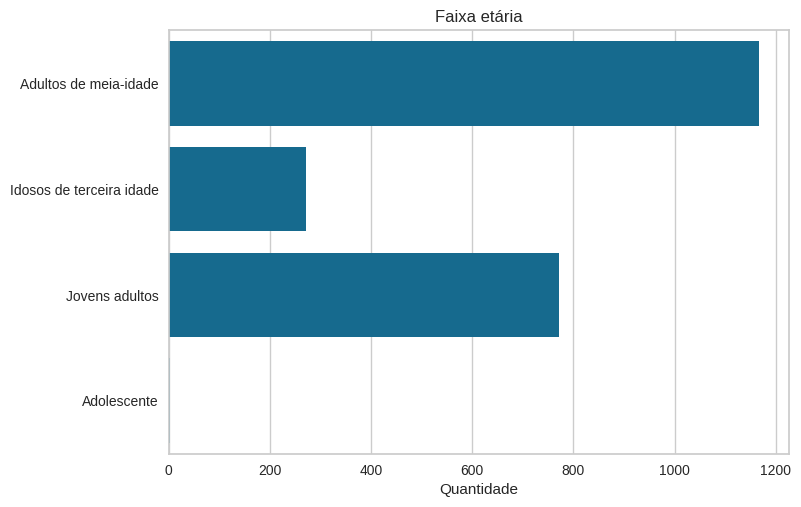

In [ ]:
# Faixa etária
fig, ax = plt.subplots()
sns.countplot(df_lim['Faixa_etaria'])
ax.set_xlabel('Quantidade')
ax.set_ylabel('')
ax.set_title('Faixa etária')
plt.show()

In [ ]:
# Ordem decrescente da Faixa etária
df_lim['Faixa_etaria'].value_counts()

,count
Faixa_etaria,
Adultos de meia-idade,1167
Jovens adultos,771
Idosos de terceira idade,272
Adolescente,3


**Análise:**

**Faixa etária dos clientes**

- 1° Adultos de meia-idade	- 1167 clientes;
- 2° Jovens adultos	- 771 clientes;
- 3° Idosos de terceira idade	- 272 clientes;
- 4° Adolescente - 3 clientes.

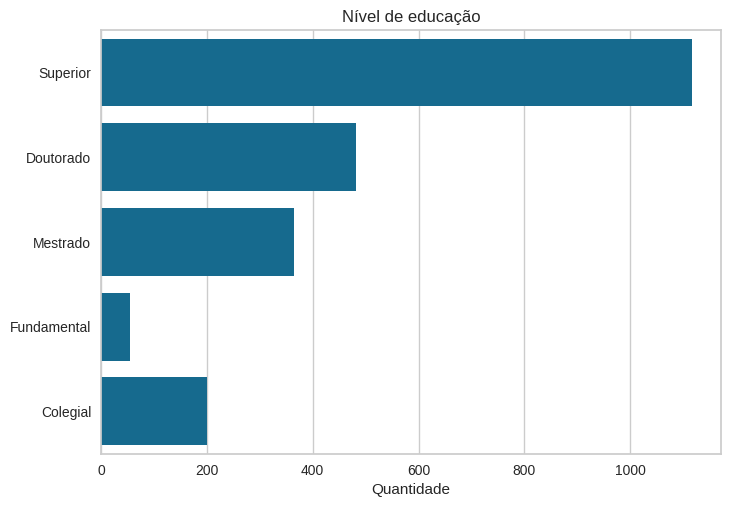

In [ ]:
# Nivel de educação
fig, ax = plt.subplots()
sns.countplot(df_lim['Nivel_educacao'])
ax.set_xlabel('Quantidade')
ax.set_ylabel('')
ax.set_title('Nível de educação')
plt.show()

In [ ]:
# Ordem decrescente do Nível de educação
df_lim['Estado_civil'].value_counts()

,count
Estado_civil,
Casado (a),857
União estável,573
Solteiro (a),478
Divorciado (a),232
Viúvo (a),76


**Análise:**

**Nível de educação dos clientes**

- 1° Casado (a)	- 857 clientes;
- 2° União estável	- 573 clientes;
- 3° Solteiro (a)	- 478 clientes;
- 4° Divorciado (a)	- 232 clientes;
- 5° Viúvo (a)	- 76 clientes.

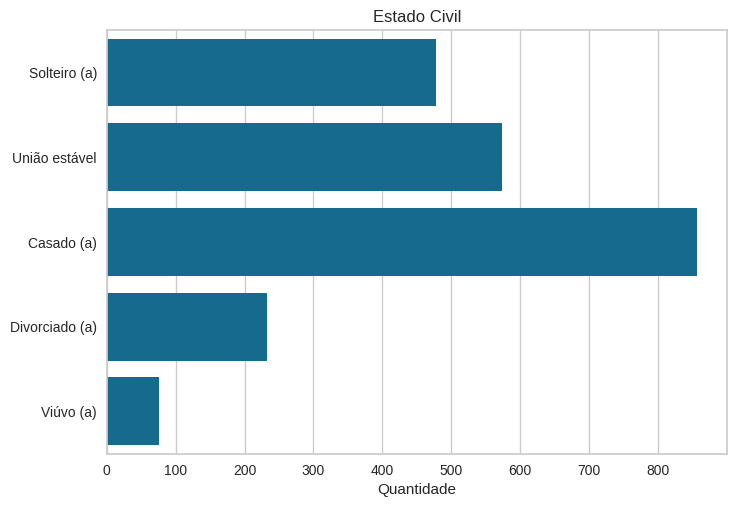

In [ ]:
# Estado civil
fig, ax = plt.subplots()
sns.countplot(df_lim['Estado_civil'])
ax.set_xlabel('Quantidade')
ax.set_ylabel('')
ax.set_title('Estado Civil')
plt.show()

In [ ]:
# Ordem decrescente do Estado civil
df_lim['Estado_civil'].value_counts()

,count
Estado_civil,
Casado (a),857
União estável,573
Solteiro (a),478
Divorciado (a),232
Viúvo (a),76


**Análise:**

**Estado Civil dos clientes**

- 1° Casado (a)	- 857 clientes;
- 2° União estável	- 573 clientes;
- 3° Solteiro (a)	- 478 clientes;
- 4° Divorciado (a)	- 232 clientes;
- 5° Viúvo (a)	- 76 clientes.

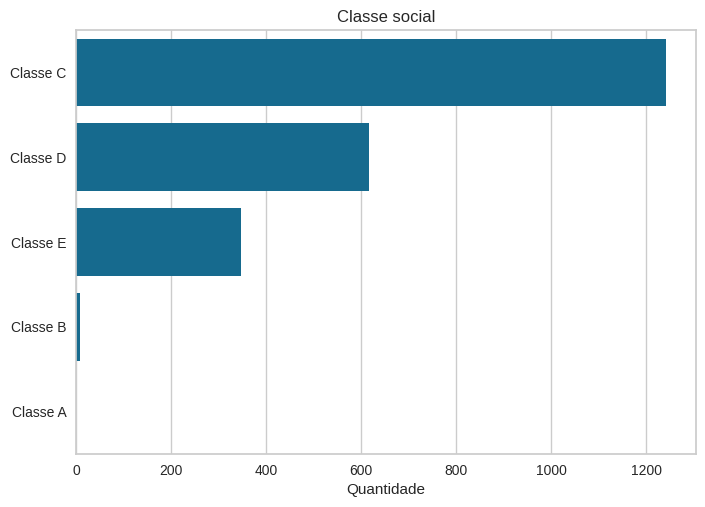

In [ ]:
# Classe social
fig, ax = plt.subplots()
sns.countplot(df_lim['Classe_social'])
ax.set_xlabel('Quantidade')
ax.set_ylabel('')
ax.set_title('Classe social')
plt.show()

In [ ]:
# Ordem decrescente das classes sociais
df_lim['Classe_social'].value_counts()

,count
Classe_social,
Classe C,1242
Classe D,617
Classe E,347
Classe B,9
Classe A,1


**Análise:**

**Classe social dos clientes**

- 1° Classe C	- 1242 clientes;
- 2° Classe D	- 617 clientes;
- 3° Classe E	- 347 clientes;
- 4° Classe B	- 9 clientes;
- 5° Classe A	- 1 cliente.

###**Canais de venda**

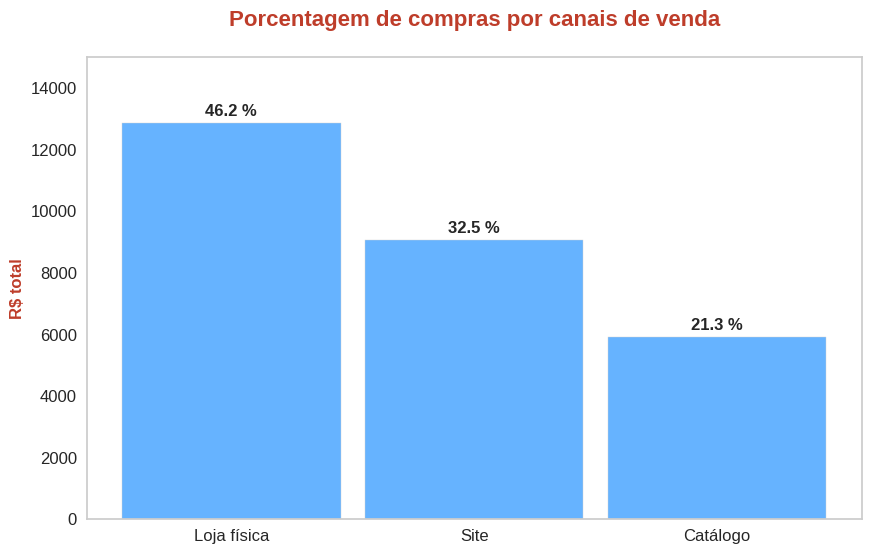

In [ ]:
# Somar as vendas totais nos 3 canais de venda
site = df_lim['n_compras_site'].sum()
catal = df_lim['Compras_catal'].sum()
loja_f = df_lim['Compras_loja_f'].sum()

# Plotar os valores dos cliques no gráfico de colunas
labels = ['Site', 'Catálogo', 'Loja física']
valores = [site, catal, loja_f]

# Dados ordenados
dados_ordenados = sorted(zip(labels, valores), key=lambda x: x[1], reverse=True)
eixo_x, eixo_y = zip(*dados_ordenados)

fig, ax = plt.subplots(figsize=(10, 6))

# width=1.0 para o espaço entre as barras
# Adicionei edgecolor='white' para criar uma linha fina de separação visual
bar_container = ax.bar(eixo_x, eixo_y, color='#66b3ff', width=0.9, edgecolor='lightgray')

# Configurações de estilo que já definimos
ax.grid(False)
ax.set_title('Porcentagem de compras por canais de venda', fontsize=16, weight='bold', color='#BE3D2A', y=1.05)
ax.set_ylabel('R$ total', fontsize=12, weight='bold', color='#BE3D2A')
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_ylim(0, 15000)

# Porcentagens
ax.bar_label(
    bar_container,
    fmt=lambda x: f'{(x/27827) * 100:.1f} %',
    fontweight='bold',
    padding=3
)

plt.show()

**Análise:**

**Vendas por canais**

- 1° Loja física	- 12.855 vendas (46,2%);
- 2° Site	9053 - 9.053 vendas (32,5%);
- 3° Catálogo - 5.919 vendas (21,3%).

###**Engajamento e conversão da campanha**

Esses KPIs ajudam a entender a eficácia das campanhas e como os clientes interagem com a empresa.

**Insight:** Ajuda a identificar qual campanha foi mais ou menos eficaz. Se uma campanha teve uma taxa de aceitação muito baixa, pode ser necessário analisar o motivo e ajustar a estratégia.

Taxa de Aceitação por Campanha: a porcentagem de clientes que clicaram nos anúncios.

In [ ]:
# Total de clientes
df_lim.shape

(2216, 41)

**Aceitou na 1°**

In [ ]:
# valores absolutos
anuncio_1_a = df_lim['Aceitou_1'].value_counts()
anuncio_1_a

,count
Aceitou_1,
0,2074
1,142


In [ ]:
# Valores relativos
df_lim['Aceitou_1'].value_counts(normalize=True) * 100

,proportion
Aceitou_1,
0,93.59
1,6.41


**Aceitou na 2°**

In [ ]:
# Valores absolutos
anuncio_2_a = df_lim['Aceitou_2'].value_counts()
anuncio_2_a

,count
Aceitou_2,
0,2186
1,30


In [ ]:
# Valores relativos
df_lim['Aceitou_2'].value_counts(normalize=True) * 100

,proportion
Aceitou_2,
0,98.65
1,1.35


**Aceitou na 3°**

In [ ]:
# Valores absolutos
anuncio_3_a = df_lim['Aceitou_3'].value_counts()
anuncio_3_a

,count
Aceitou_3,
0,2053
1,163


In [ ]:
2053+163

2216

In [ ]:
# Valores relativos
df_lim['Aceitou_3'].value_counts(normalize=True) * 100

,proportion
Aceitou_3,
0,92.64
1,7.36


**Aceitou na 4°**

In [ ]:
# Valores absolutos
anuncio_4_a = df_lim['Aceitou_4'].value_counts()
anuncio_4_a

,count
Aceitou_4,
0,2052
1,164


In [ ]:
# Valores relativos
df_lim['Aceitou_4'].value_counts(normalize=True) * 100

,proportion
Aceitou_4,
0,92.60
1,7.40


**Aceitou na 5°**

In [ ]:
# Valores absolutos
anuncio_5_a = df_lim['Aceitou_5'].value_counts()
anuncio_5_a

,count
Aceitou_5,
0,2054
1,162


In [ ]:
# Valores relativos
df_lim['Aceitou_5'].value_counts(normalize=True) * 100

,proportion
Aceitou_5,
0,92.69
1,7.31


**Aceitou na última**

In [ ]:
# Valores absolutos
anuncio_6_a = df_lim['Aceitou_na_ultima'].value_counts()
anuncio_6_a

,count
Aceitou_na_ultima,
0,1883
1,333


In [ ]:
# Valores relativos
df_lim['Aceitou_na_ultima'].value_counts(normalize=True) * 100

,proportion
Aceitou_na_ultima,
0,84.97
1,15.03


In [ ]:
# Calcule o total de cliques nos anúncios
total_cliques = sum([anuncio_1_a[1], anuncio_2_a[1], anuncio_3_a[1], anuncio_4_a[1], anuncio_5_a[1], anuncio_6_a[1]])
total_cliques

np.int64(994)

In [ ]:
# Calcule o total de não cliques nos anúncios
total_n_cliques = sum([anuncio_1_a[0], anuncio_2_a[0], anuncio_3_a[0], anuncio_4_a[0], anuncio_5_a[0], anuncio_6_a[0]])
total_n_cliques

np.int64(12302)

In [ ]:
# Some o total de cliques
total_cliques + total_n_cliques

np.int64(13296)

In [ ]:
porc_t = ['Aceitou_1', 'Aceitou_2', 'Aceitou_3', 'Aceitou_4', 'Aceitou_5', 'Aceitou_na_ultima']

total_cliques = 0
total_n_cliques = 0

for i in porc_t:
    # Soma dos valores 1 (clicou)
    total_cliques += df_lim[i].sum()
    # Soma dos valores 0 (Não clicou)
    total_n_cliques += (df_lim.shape[0] - df_lim[i].sum())

print(f"Total de cliques em todas as campanhas: {total_cliques}")
print(f"Total de não cliques em todas as campanhas: {total_n_cliques}")

Total de cliques em todas as campanhas: 994
Total de não cliques em todas as campanhas: 12302


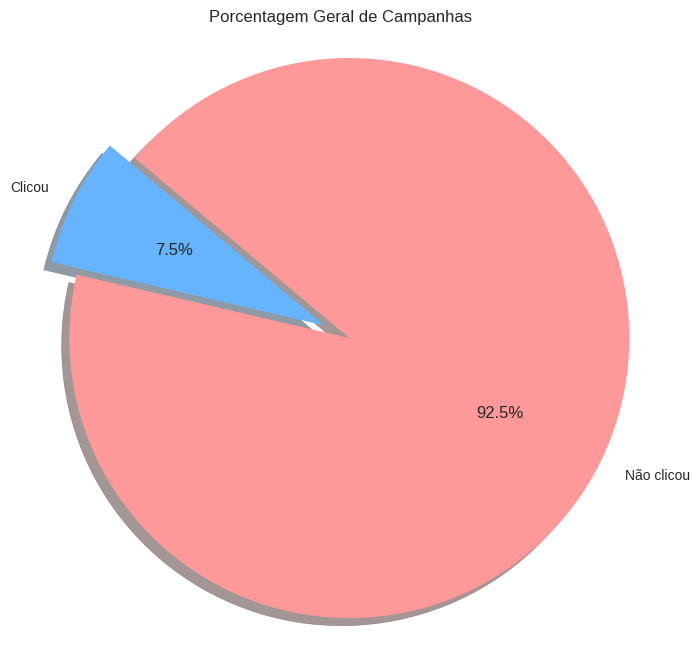

In [ ]:
# Calcule o total de cliques e não cliques
total_c = total_cliques
total_n_c = total_n_cliques

# Salvando os parâmetros dentro das variáveis
rotulos = ['Clicou', 'Não clicou']
total = [total_c, total_n_c]
cores = ['#66b3ff', '#ff9999']
limites = (0.1, 0)

plt.figure(figsize=(8, 8))
plt.pie(total, explode=limites, labels=rotulos, colors=cores, autopct='%1.1f%%',
        shadow=True, startangle=140)
plt.axis('equal')
plt.title('Porcentagem Geral de Campanhas')
plt.show()

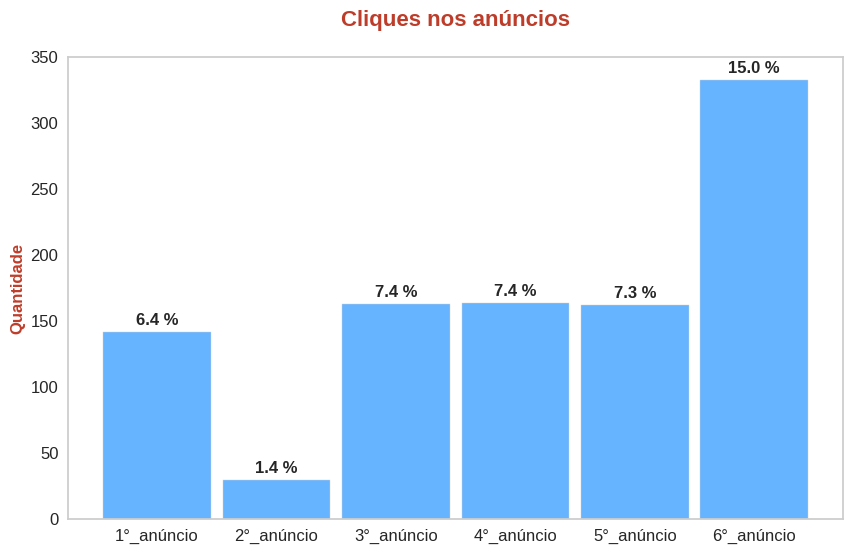

In [ ]:
# Plotar os valores dos cliques no gráfico de colunas
labels = ['1°_anúncio', '2°_anúncio', '3°_anúncio', '4°_anúncio', '5°_anúncio', '6°_anúncio']
valores = [anuncio_1_a[1], anuncio_2_a[1], anuncio_3_a[1], anuncio_4_a[1], anuncio_5_a[1], anuncio_6_a[1]]

# Dados ordenados (mantendo a lógica anterior)
dados_ordenados = sorted(zip(labels, valores))
eixo_x, eixo_y = zip(*dados_ordenados)

fig, ax = plt.subplots(figsize=(10, 6))

# width=1.0 para o espaço entre as barras
# Adicionei edgecolor='white' para criar uma linha fina de separação visual
bar_container = ax.bar(eixo_x, eixo_y, color='#66b3ff', width=0.9, edgecolor='lightgray')

# Configurações de estilo que já definimos
ax.grid(False)
ax.set_title('Cliques nos anúncios', fontsize=16, weight='bold', color='#BE3D2A', y=1.05)
ax.set_ylabel('Quantidade', fontsize=12, weight='bold', color='#BE3D2A')
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_ylim(0, 350)

# Porcentagens
ax.bar_label(
    bar_container,
    fmt=lambda x: f'{(x/2216) * 100:.1f} %',
    fontweight='bold',
    padding=3
)

plt.show()

In [ ]:
2216*6

13296

In [ ]:
# Custo por Aceitação (Cost Per Acquisition - CPA)
df_lim['Valor_contato'].value_counts()

,count
Valor_contato,
3,2216


**Análise:** o custo médio é de R$ 3,00. Esse KPI já veio calculado no dataset.

In [ ]:
# Receita Média por Aceitação (Average Revenue Per Accepted Offer - ARPA)
df_lim['Valor_apos_ac'].value_counts()

,count
Valor_apos_ac,
11,2216


O custo médio é de R$ 11,00. Esse KPI já veio calculado no dataset.

**Análise:**

**Campanha total**

- Cada um dos 6 anúncios foi exibido 2.216 vezes, ou seja, um total de 13.296 exibições;

- Dessas 13.296 exibições, 994 leads (possíveis clientes) clicaram, o que representa 7,5%, e 12.302 não clicaram, o que representa 92,5%;

**Quantidade de cliques em cada anúncio, que foi exibido 2.216 vezes**

- 1° anúncio: 142 (6,44%);

- 2° anúncio: 30 (1,36%);

- 3° anúncio: 163 (7,39%);

- 4° anúncio: 164 (7,44%);

- 5° anúncio: 162 (7,3%);

- 6° anúncio: 333 (15,1%).

**Crescimento/ declínio percentual = (Valor Final - Valor Inicial) ÷ Valor Inicial × 100**

- Declínio de 78 % do 1° para o 2° anúncio;
- Crescimento de 443 % do 2° para o 3° anúncio;
- Crescimento de 0,6 % do 3° para o 4° anúncio;
- Declínio de 1,2 % do 4° para o 5° anúncio;
- Crescimento de 105 % do 5° para o 6° anúncio.

Fonte: https://berryconsult.com/blog/o-que-e-taxa-de-crescimento

**CPA - Cost Per Acquisition (Custo por Aceitação): R$ 3,00**

- Esse indicador mede o custo médio para converter um cliente, quanto menor, melhor.

**ARPA - Average Revenue Per Accepted Offer (Receita Média por Aceitação): R$ 11,00**

- Esse indicador mede o valor médio gasto por cada cliente após clicar em um anúncio.

**Observações.:**

- Não é possível mensurar o ROI (Retorno sobre o investimento) porque não tem o custo total da campanha no dataset, mas o ideal seria um ROI positivo caso houvesse;

- Não é possível segmentar quais produtos foram anunciados em cada um dos anúncios nem quais obtiveram conversão.

### Receita x Quantidade

In [ ]:
# Quantidade total de vendas
df_lim['ID'].count()

np.int64(2216)

In [ ]:
# Receita total
Receita_total = df_lim['Receita_total'].sum()

In [ ]:
# Calcule o ticket médio
ticket_medio = df_lim['Receita_total'].sum() / df_lim['ID'].count()
ticket_medio

np.float64(607.0753610108303)

**Análise:**

* A receita total do período foi de R$ 1.345.279,00 (soma de todo o valor de todas as vendas);

* O ticket médio foi de R$ 607,07 (receita total dividida pela quantidade total de clientes);

**Observações:**

* Como não tem dados sobre os custos, então não dá para calcular o lucro (receita - custos = lucro).

In [ ]:
# Receitas totais por categoria de produto
Vinho = df_lim['Valor_p_vinho'].sum()
Frutas = df_lim['Valor_p_frutas'].sum()
Carne = df_lim['Valor_p_carne'].sum()
Pesca = df_lim['Valor_p_pesca'].sum()
Doces = df_lim['Valor_p_doces'].sum()
Ouro = df_lim['Valor_p_ouro'].sum()

# Em porcentagem
Vinho_r = round(((Vinho / Receita_total) * 100), 2)
Frutas_r = round(((Frutas / Receita_total) * 100), 2)
Carne_r = round(((Carne / Receita_total) * 100), 2)
Pesca_r = round(((Pesca / Receita_total) * 100), 2)
Doces_r = round(((Doces / Receita_total) * 100), 2)
Ouro_r = round(((Ouro / Receita_total) * 100), 2)

print(f"Receita total: R${Receita_total}")
print("\nUm milhão, trezentos e quarenta e cinco mil e duzentos e setenta e nove reais")
print("\nDividida por categoria de produto:\n")
print(f"Vinho: R${Vinho} ou {Vinho_r}% da receita")
print(f"Frutas: R${Frutas} ou {Frutas_r}% da receita")
print(f"Carne: R${Carne} ou {Carne_r}% da receita")
print(f"Pesca: R${Pesca} ou {Pesca_r}% da receita")
print(f"Doces: R${Doces} ou {Doces_r}% da receita")
print(f"Ouro: R${Ouro} ou {Ouro_r}% da receita")

Receita total: R$1345279

Um milhão, trezentos e quarenta e cinco mil e duzentos e setenta e nove reais

Dividida por categoria de produto:

Vinho: R$676083 ou 50.26% da receita
Frutas: R$58405 ou 4.34% da receita
Carne: R$370063 ou 27.51% da receita
Pesca: R$83405 ou 6.2% da receita
Doces: R$59896 ou 4.45% da receita
Ouro: R$97427 ou 7.24% da receita


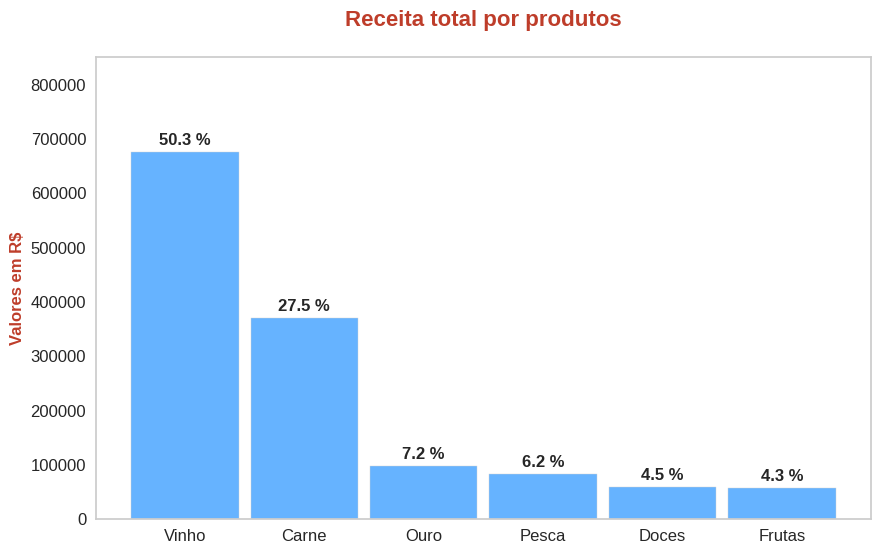

In [ ]:
# Dados
labels = ['Vinho', 'Frutas', 'Carne', 'Pesca', 'Doces', 'Ouro']
valores = [Vinho, Frutas, Carne, Pesca, Doces, Ouro]

# Dados ordenados (mantendo a lógica anterior)
dados_ordenados = sorted(zip(labels, valores), key=lambda x: x[1], reverse=True)
eixo_x, eixo_y = zip(*dados_ordenados)

fig, ax = plt.subplots(figsize=(10, 6))

# O segredo está no width=1.0
# Adicionei edgecolor='white' para criar uma linha fina de separação visual
bar_container = ax.bar(eixo_x, eixo_y, color='#66b3ff', width=0.9, edgecolor='lightgray')
#5DADE2
# Configurações de estilo que já definimos
ax.grid(False)
ax.set_title('Receita total por produtos', fontsize=16, weight='bold', color='#BE3D2A', y=1.05)
ax.set_ylabel('Valores em R$', fontsize=12, weight='bold', color='#BE3D2A')
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_ylim(0, 850000)

# Porcentagens
ax.bar_label(
    bar_container,
    fmt=lambda x: f'{(x/Receita_total) * 100:.1f} %',
    fontweight='bold',
    padding=3
)

plt.show()

In [ ]:
# Receita
total_prod_r = df_lim[['Valor_p_vinho', 'Valor_p_frutas', 'Valor_p_carne', 'Valor_p_pesca', 'Valor_p_doces', 'Valor_p_ouro']].sum()
total_prod_r_df = total_prod_r.reset_index()
total_prod_r_df.columns = ['Categoria', 'Receita']
total_prod_r_df

,Categoria,Receita
0,Valor_p_vinho,676083
1,Valor_p_frutas,58405
2,Valor_p_carne,370063
3,Valor_p_pesca,83405
4,Valor_p_doces,59896
5,Valor_p_ouro,97427


In [ ]:
# Criando o dicionário para renomear os dados
cat = {'Valor_p_vinho': 'Vinho',
         'Valor_p_frutas': 'Frutas',
         'Valor_p_carne': 'Carne',
         'Valor_p_pesca': 'Pesca',
         'Valor_p_doces': 'Doces',
         'Valor_p_ouro': 'Ouro'}

In [ ]:
total_prod_r_df['Categoria'] = total_prod_r_df['Categoria'].replace(cat)

In [ ]:
total_prod_r_df

,Categoria,Receita
0,Vinho,676083
1,Frutas,58405
2,Carne,370063
3,Pesca,83405
4,Doces,59896
5,Ouro,97427


In [ ]:
# Quantidade
total_prod_q = df_lim[['Valor_p_vinho', 'Valor_p_frutas', 'Valor_p_carne', 'Valor_p_pesca', 'Valor_p_doces', 'Valor_p_ouro']]
total_prod_q = (total_prod_q != 0).sum()
total_prod_q_df = total_prod_q.reset_index()
total_prod_q_df.columns = ['Categoria', 'Quantidade']
total_prod_q_df

,Categoria,Quantidade
0,Valor_p_vinho,2203
1,Valor_p_frutas,1821
2,Valor_p_carne,2215
3,Valor_p_pesca,1837
4,Valor_p_doces,1803
5,Valor_p_ouro,2155


In [ ]:
# Renomear
total_prod_q_df['Categoria'] = total_prod_q_df['Categoria'].replace(cat)

In [ ]:
total_prod_q_df

,Categoria,Quantidade
0,Vinho,2203
1,Frutas,1821
2,Carne,2215
3,Pesca,1837
4,Doces,1803
5,Ouro,2155


In [ ]:
Quantidade_total = total_prod_q_df['Quantidade'].sum()
Quantidade_total

np.int64(12034)

In [ ]:
# Quantidade totais por categoria de produto
# Extrair quantidades da coluna total_prod_q_df
Vinho = total_prod_q_df[total_prod_q_df['Categoria'] == 'Vinho']['Quantidade'].iloc[0]
Frutas = total_prod_q_df[total_prod_q_df['Categoria'] == 'Frutas']['Quantidade'].iloc[0]
Carne = total_prod_q_df[total_prod_q_df['Categoria'] == 'Carne']['Quantidade'].iloc[0]
Pesca = total_prod_q_df[total_prod_q_df['Categoria'] == 'Pesca']['Quantidade'].iloc[0]
Doces = total_prod_q_df[total_prod_q_df['Categoria'] == 'Doces']['Quantidade'].iloc[0]
Ouro = total_prod_q_df[total_prod_q_df['Categoria'] == 'Ouro']['Quantidade'].iloc[0]

# Em porcentagem
Vinho_q = round(((Vinho / Quantidade_total) * 100), 2)
Frutas_q = round(((Frutas / Quantidade_total) * 100), 2)
Carne_q = round(((Carne / Quantidade_total) * 100), 2)
Pesca_q = round(((Pesca / Quantidade_total) * 100), 2)
Doces_q = round(((Doces / Quantidade_total) * 100), 2)
Ouro_q = round(((Ouro / Quantidade_total) * 100), 2)

print(f"Quantidade total:{Quantidade_total}")
print("\nDividida por categoria de produto:\n")
print(f"Vinho: {Vinho} ou {Vinho_q}% do total")
print(f"Frutas: {Frutas} ou {Frutas_q}% do total")
print(f"Carne: {Carne} ou {Carne_q}% do total")
print(f"Pesca: {Pesca} ou {Pesca_q}% do total")
print(f"Doces: {Doces} ou {Doces_q}% do total")
print(f"Ouro: {Ouro} ou {Ouro_q}% do total")

Quantidade total:12034

Dividida por categoria de produto:

Vinho: 2203 ou 18.31% do total
Frutas: 1821 ou 15.13% do total
Carne: 2215 ou 18.41% do total
Pesca: 1837 ou 15.27% do total
Doces: 1803 ou 14.98% do total
Ouro: 2155 ou 17.91% do total


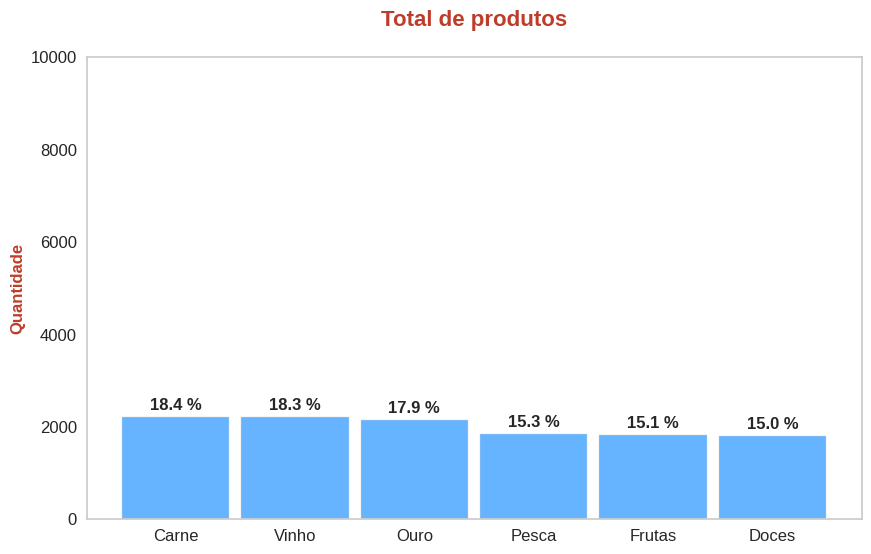

In [ ]:
# Dados
labels = ['Vinho', 'Frutas', 'Carne', 'Pesca', 'Doces', 'Ouro']
valores = [Vinho, Frutas, Carne, Pesca, Doces, Ouro]

# Dados ordenados (mantendo a lógica anterior)
dados_ordenados = sorted(zip(labels, valores), key=lambda x: x[1], reverse=True)
eixo_x, eixo_y = zip(*dados_ordenados)

fig, ax = plt.subplots(figsize=(10, 6))

# O segredo está no width=1.0
# Adicionei edgecolor='white' para criar uma linha fina de separação visual
bar_container = ax.bar(eixo_x, eixo_y, color='#66b3ff', width=0.9, edgecolor='lightgray')
#5DADE2
# Configurações de estilo que já definimos
ax.grid(False)
ax.set_title('Total de produtos', fontsize=16, weight='bold', color='#BE3D2A', y=1.05)
ax.set_ylabel('Quantidade', fontsize=12, weight='bold', color='#BE3D2A')
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_ylim(0, 10000)

# Porcentagens
ax.bar_label(
    bar_container,
    fmt=lambda x: f'{(x/Quantidade_total) * 100:.1f} %',
    fontweight='bold',
    padding=3
)

plt.show()

**Análise:**

Receitas  em ordem decrescente (do maior para o menor)

- 1° Vinho: 676.083 reais (50.26 %);
- 2° Carne: 370.063 reais (27.51 %);
- 3° Ouro: 97.427 reais (7.24 %);
- 4° Pesca: 83.405 reais (6.2 %);
- 5° Doces: 59.896 reais (4.45 %);
- 6° Frutas: 58.405 reais (4.34 %).

Quantidades em ordem decrescente (do maior para o menor)

- 1° Carne: 2215 unidades (18.41%);
- 2° Vinho: 2203 unidades (18.31%);
- 3° Ouro: 2155 unidades (17.91%);
- 4° Pesca: 1837 unidades (15.27%);
- 5° Frutas: 1821 unidades (15.13%);
- 6° Doces: 1803 unidades (14.98%).

Ao analisar os dois gráficos nota-se que as quantidades de produtos vendidos são bem equilibradas, variando de 15% a 18%, porém a diferença está no valor dos produtos. O vinho é responsável por mais da metade do faturamento da empresa, seguido pela carne, ouro, pesca, doces e frutas, sendo que as quantidades vendidas são quase iguais. A conclusão é que o vinho e a carne são os dois produtos mais caros.

**Recomendações:**

- Manter altas as vendas dos dois produtos mais vendidos (vinho e carne) com cupons exclusivos de descontos para os clientes que consomem com mais frequência. Esses cupons podem ser enviados por email para que sejam utilizados em qualquer um dos canais de compra (loja física, catálogo ou site). No site, bastando apenas inserir o código na hora de fechar o carrinho;

- Invetir em marketing para elevar as vendas dos produtos que não chegam a 10% das receitas (ouro, pesca, doces e frutas). Pode ser melhorando as campanhas também porque provavelmente nelas já são feitas propagandas desses produtos. Para isso será necessário coletar mais dados sobre as campanhas de forma segmentada, ou seja, saber quais produtos são anunciados nas campanhas 1, 2, 3, 4, 5 e 6, e depois de clicarem nos anúncios, criar estratégias para prender esses leads e fazer a conversão;

- Recomendar esses produtos na hora que o cliente estiver fechando o carrinho de compras e oferecer descontos como incentivo.

### Segmentação da receita

In [ ]:
# Por estado civil
df_lim.groupby(['Estado_civil'])[['Receita_total']].sum().sort_values(by='Receita_total', ascending=False)

,Receita_total
Estado_civil,
Casado (a),506885
União estável,348869
Solteiro (a),292534
Divorciado (a),141666
Viúvo (a),55325


In [ ]:
# Receita total
506885 + 348869 + 292534 + 141666 + 55325

1345279

In [ ]:
# Por faixa etária
df_lim.groupby(['Faixa_etaria'])[['Receita_total']].sum().sort_values(by='Receita_total', ascending=False)

,Receita_total
Faixa_etaria,
Adultos de meia-idade,715256
Jovens adultos,423540
Idosos de terceira idade,201621
Adolescente,2922


In [ ]:
# Receita total (foi retirado 3 pessoas de idades muito avançadas, por isso resultou em um valor menor)
715256 + 423540 + 201621 + 2922

1343339

In [ ]:
# Por nível de educação
df_lim.groupby(['Nivel_educacao'])[['Receita_total']].sum().sort_values(by='Receita_total', ascending=False)

,Receita_total
Nivel_educacao,
Superior,693802
Doutorado,325509
Mestrado,222565
Colegial,98986
Fundamental,4417


In [ ]:
# Receita total
693802 + 325509 + 222565 + 98986 + 4417

1345279

In [ ]:
# Por classe social
df_lim.groupby(['Classe_social'])[['Receita_total']].sum().sort_values(by='Receita_total', ascending=False)

,Receita_total
Classe_social,
Classe C,1215373
Classe D,97549
Classe E,25059
Classe B,7236
Classe A,62


In [ ]:
# Receita total
1215373 + 97549 + 25059 + 7236 + 62

1345279

### Segmentação dos produtos vendidos

Cria segmentos de clientes com base em seus hábitos de compra.

#### Estado civil

In [ ]:
# Valores absolutos
df_lim.groupby(['Estado_civil'])[['Valor_p_vinho', 'Valor_p_frutas', 'Valor_p_carne', 'Valor_p_pesca', 'Valor_p_doces', 'Valor_p_ouro',]].sum().sort_values(by='Estado_civil', ascending=False)

,Valor_p_vinho,Valor_p_frutas,Valor_p_carne,Valor_p_pesca,Valor_p_doces,Valor_p_ouro
Estado_civil,,,,,,
Viúvo (a),27902,2422,14085,3793,2878,4245
União estável,176715,14612,95374,22383,15031,24754
Solteiro (a),139126,13027,87868,18704,12839,20970
Divorciado (a),75364,6363,34848,8130,6222,10739
Casado (a),256976,21981,137888,30395,22926,36719


In [ ]:
# Valores relativos

# Calcular a soma total de cada coluna
soma_total = df_lim[['Valor_p_vinho', 'Valor_p_frutas', 'Valor_p_carne', 'Valor_p_pesca', 'Valor_p_doces', 'Valor_p_ouro']].sum()

# Agrupar por 'Estado_civil' e somar os valores
df_agrupado = df_lim.groupby(['Estado_civil'])[['Valor_p_vinho', 'Valor_p_frutas', 'Valor_p_carne', 'Valor_p_pesca', 'Valor_p_doces', 'Valor_p_ouro']].sum()

# Dividir cada valor pelo total da coluna e multiplicar por 100 para obter a porcentagem
df_porcentagem = (df_agrupado / soma_total) * 100

# Exibir o DataFrame com os valores em porcentagem, ordenando por 'Estado_civil' de forma decrescente
print(df_porcentagem.sort_values(by='Estado_civil', ascending=False))

                Valor_p_vinho  Valor_p_frutas  Valor_p_carne  Valor_p_pesca  \
Estado_civil                                                                  
Viúvo (a)                4.13            4.15           3.81           4.55   
União estável           26.14           25.02          25.77          26.84   
Solteiro (a)            20.58           22.30          23.74          22.43   
Divorciado (a)          11.15           10.89           9.42           9.75   
Casado (a)              38.01           37.64          37.26          36.44   

                Valor_p_doces  Valor_p_ouro  
Estado_civil                                 
Viúvo (a)                4.80          4.36  
União estável           25.10         25.41  
Solteiro (a)            21.44         21.52  
Divorciado (a)          10.39         11.02  
Casado (a)              38.28         37.69  


In [ ]:
# Valor médio de compras
df_lim.groupby(['Estado_civil'])[['Valor_p_vinho', 'Valor_p_frutas', 'Valor_p_carne', 'Valor_p_pesca', 'Valor_p_doces', 'Valor_p_ouro',]].mean().sort_values(by='Estado_civil', ascending=False)

,Valor_p_vinho,Valor_p_frutas,Valor_p_carne,Valor_p_pesca,Valor_p_doces,Valor_p_ouro
Estado_civil,,,,,,
Viúvo (a),367.13,31.87,185.33,49.91,37.87,55.86
União estável,308.40,25.50,166.45,39.06,26.23,43.20
Solteiro (a),291.06,27.25,183.82,39.13,26.86,43.87
Divorciado (a),324.84,27.43,150.21,35.04,26.82,46.29
Casado (a),299.86,25.65,160.90,35.47,26.75,42.85


#### Nível de educação

In [ ]:
# Valores absolutos
df_lim.groupby(['Nivel_educacao'])[['Valor_p_vinho', 'Valor_p_frutas', 'Valor_p_carne', 'Valor_p_pesca', 'Valor_p_doces', 'Valor_p_ouro',]].sum().sort_values(by='Nivel_educacao', ascending=False)

,Valor_p_vinho,Valor_p_frutas,Valor_p_carne,Valor_p_pesca,Valor_p_doces,Valor_p_ouro
Nivel_educacao,,,,,,
Superior,318111,34441,201319,48453,34915,56563
Mestrado,121538,7802,59466,11495,7595,14669
Fundamental,391,600,618,921,654,1233
Doutorado,195874,9690,81644,12928,9787,15586
Colegial,40169,5872,27016,9608,6945,9376


In [ ]:
# Valores relativos

# Foi usada o mesmo comando de soma de colunas do código anterior
# Agrupar por 'Estado_civil' e somar os valores
df_agrupado_e = df_lim.groupby(['Nivel_educacao'])[['Valor_p_vinho', 'Valor_p_frutas', 'Valor_p_carne', 'Valor_p_pesca', 'Valor_p_doces', 'Valor_p_ouro']].sum()

# Dividir cada valor pelo total da coluna e multiplicar por 100 para obter a porcentagem
df_porcentagem = (df_agrupado_e / soma_total) * 100

# Exibir o DataFrame com os valores em porcentagem, ordenando por 'Estado_civil' de forma decrescente
print(df_porcentagem.sort_values(by='Nivel_educacao', ascending=False))

                Valor_p_vinho  Valor_p_frutas  Valor_p_carne  Valor_p_pesca  \
Nivel_educacao                                                                
Superior                47.05           58.97          54.40          58.09   
Mestrado                17.98           13.36          16.07          13.78   
Fundamental              0.06            1.03           0.17           1.10   
Doutorado               28.97           16.59          22.06          15.50   
Colegial                 5.94           10.05           7.30          11.52   

                Valor_p_doces  Valor_p_ouro  
Nivel_educacao                               
Superior                58.29         58.06  
Mestrado                12.68         15.06  
Fundamental              1.09          1.27  
Doutorado               16.34         16.00  
Colegial                11.60          9.62  


In [ ]:
# Valor médio de compras
df_lim.groupby(['Nivel_educacao'])[['Valor_p_vinho', 'Valor_p_frutas', 'Valor_p_carne', 'Valor_p_pesca', 'Valor_p_doces', 'Valor_p_ouro',]].mean().sort_values(by='Nivel_educacao', ascending=False)

,Valor_p_vinho,Valor_p_frutas,Valor_p_carne,Valor_p_pesca,Valor_p_doces,Valor_p_ouro
Nivel_educacao,,,,,,
Superior,285.05,30.86,180.39,43.42,31.29,50.68
Mestrado,332.98,21.38,162.92,31.49,20.81,40.19
Fundamental,7.24,11.11,11.44,17.06,12.11,22.83
Doutorado,407.22,20.15,169.74,26.88,20.35,32.40
Colegial,200.84,29.36,135.08,48.04,34.73,46.88


#### Faixa etária

In [ ]:
# Valores absolutos
df_lim.groupby(['Faixa_etaria'])[['Valor_p_vinho', 'Valor_p_frutas', 'Valor_p_carne', 'Valor_p_pesca', 'Valor_p_doces', 'Valor_p_ouro',]].sum().sort_values(by='Faixa_etaria', ascending=False)

,Valor_p_vinho,Valor_p_frutas,Valor_p_carne,Valor_p_pesca,Valor_p_doces,Valor_p_ouro
Faixa_etaria,,,,,,
Jovens adultos,193413,20476,127102,29386,21152,32011
Idosos de terceira idade,106556,7575,53691,12024,8210,13565
Adultos de meia-idade,374203,30108,187460,41752,30282,51451
Adolescente,1133,96,1235,125,184,149


In [ ]:
# Valores relativos

# Foi usada o mesmo comando de soma de colunas do código anterior
# Agrupar por 'Estado_civil' e somar os valores
df_agrupado_e = df_lim.groupby(['Faixa_etaria'])[['Valor_p_vinho', 'Valor_p_frutas', 'Valor_p_carne', 'Valor_p_pesca', 'Valor_p_doces', 'Valor_p_ouro']].sum()

# Dividir cada valor pelo total da coluna e multiplicar por 100 para obter a porcentagem
df_porcentagem = (df_agrupado_e / soma_total) * 100

# Exibir o DataFrame com os valores em porcentagem, ordenando por 'Estado_civil' de forma decrescente
print(df_porcentagem.sort_values(by='Faixa_etaria', ascending=False))

                          Valor_p_vinho  Valor_p_frutas  Valor_p_carne  \
Faixa_etaria                                                             
Jovens adultos                    28.61           35.06          34.35   
Idosos de terceira idade          15.76           12.97          14.51   
Adultos de meia-idade             55.35           51.55          50.66   
Adolescente                        0.17            0.16           0.33   

                          Valor_p_pesca  Valor_p_doces  Valor_p_ouro  
Faixa_etaria                                                          
Jovens adultos                    35.23          35.31         32.86  
Idosos de terceira idade          14.42          13.71         13.92  
Adultos de meia-idade             50.06          50.56         52.81  
Adolescente                        0.15           0.31          0.15  


In [ ]:
# Valor médio de compras
df_lim.groupby(['Faixa_etaria'])[['Valor_p_vinho', 'Valor_p_frutas', 'Valor_p_carne', 'Valor_p_pesca', 'Valor_p_doces', 'Valor_p_ouro',]].mean().sort_values(by='Faixa_etaria', ascending=False)

,Valor_p_vinho,Valor_p_frutas,Valor_p_carne,Valor_p_pesca,Valor_p_doces,Valor_p_ouro
Faixa_etaria,,,,,,
Jovens adultos,250.86,26.56,164.85,38.11,27.43,41.52
Idosos de terceira idade,391.75,27.85,197.39,44.21,30.18,49.87
Adultos de meia-idade,320.65,25.80,160.63,35.78,25.95,44.09
Adolescente,377.67,32.00,411.67,41.67,61.33,49.67


#### Classe Social

In [ ]:
# Valores absolutos
df_lim.groupby(['Classe_social'])[['Valor_p_vinho', 'Valor_p_frutas', 'Valor_p_carne', 'Valor_p_pesca', 'Valor_p_doces', 'Valor_p_ouro',]].sum().sort_values(by='Classe_social', ascending=False)

,Valor_p_vinho,Valor_p_frutas,Valor_p_carne,Valor_p_pesca,Valor_p_doces,Valor_p_ouro
Classe_social,,,,,,
Classe E,4374,2072,7469,2863,2219,6062
Classe D,47136,4086,22294,6462,4036,13535
Classe C,623346,52028,335218,73843,53348,77590
Classe B,1218,205,5064,229,292,228
Classe A,9,14,18,8,1,12


In [ ]:
# Valores relativos

# Foi usada o mesmo comando de soma de colunas do código anterior
# Agrupar por 'Estado_civil' e somar os valores
df_agrupado_e = df_lim.groupby(['Classe_social'])[['Valor_p_vinho', 'Valor_p_frutas', 'Valor_p_carne', 'Valor_p_pesca', 'Valor_p_doces', 'Valor_p_ouro']].sum()

# Dividir cada valor pelo total da coluna e multiplicar por 100 para obter a porcentagem
df_porcentagem = (df_agrupado_e / soma_total) * 100

# Exibir o DataFrame com os valores em porcentagem, ordenando por 'Estado_civil' de forma decrescente
print(df_porcentagem.sort_values(by='Classe_social', ascending=False))

               Valor_p_vinho  Valor_p_frutas  Valor_p_carne  Valor_p_pesca  \
Classe_social                                                                
Classe E                0.65            3.55           2.02           3.43   
Classe D                6.97            7.00           6.02           7.75   
Classe C               92.20           89.08          90.58          88.54   
Classe B                0.18            0.35           1.37           0.27   
Classe A                0.00            0.02           0.00           0.01   

               Valor_p_doces  Valor_p_ouro  
Classe_social                               
Classe E                3.70          6.22  
Classe D                6.74         13.89  
Classe C               89.07         79.64  
Classe B                0.49          0.23  
Classe A                0.00          0.01  


In [ ]:
# Valor médio de compras
df_lim.groupby(['Classe_social'])[['Valor_p_vinho', 'Valor_p_frutas', 'Valor_p_carne', 'Valor_p_pesca', 'Valor_p_doces', 'Valor_p_ouro',]].mean().sort_values(by='Classe_social', ascending=False)

,Valor_p_vinho,Valor_p_frutas,Valor_p_carne,Valor_p_pesca,Valor_p_doces,Valor_p_ouro
Classe_social,,,,,,
Classe E,12.61,5.97,21.52,8.25,6.39,17.47
Classe D,76.40,6.62,36.13,10.47,6.54,21.94
Classe C,501.89,41.89,269.90,59.45,42.95,62.47
Classe B,135.33,22.78,562.67,25.44,32.44,25.33
Classe A,9.00,14.00,18.00,8.00,1.00,12.00


In [ ]:
# Preferências por canais de compras de acordo com o estado civil
df_lim.groupby(['Estado_civil'])[['Compras_catal', 'Compras_loja_f', 'n_compras_site']].sum()

,Compras_catal,Compras_loja_f,n_compras_site
Estado_civil,,,
Casado (a),2254,5013,3501
Divorciado (a),620,1350,1000
Solteiro (a),1259,2711,1850
União estável,1535,3298,2351
Viúvo (a),251,483,351


### Reclamações

In [ ]:
# Valores absolutos
df_lim['Reclamou'].value_counts()

,count
Reclamou,
0,2195
1,21


In [ ]:
2195 + 21

2216

In [ ]:
# Valores relativos
df_lim['Reclamou'].value_counts(normalize=True) * 100

,proportion
Reclamou,
0,99.05
1,0.95


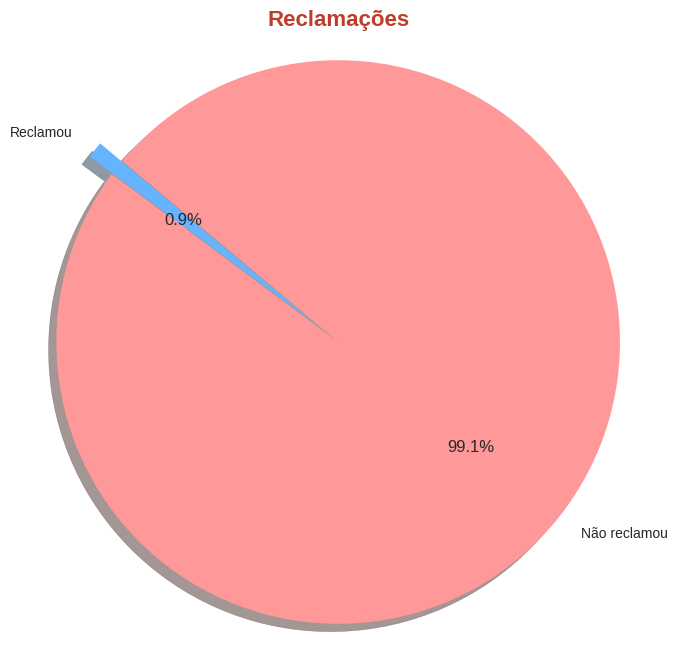

In [ ]:
# Crie duas variáveis para armazenar os valores 0 e 1 (reclamou e não reclamou)
rec = df_lim['Reclamou'].value_counts()[1]
n_rec = df_lim['Reclamou'].value_counts()[0]

# Plotar no gráfico de pizza
rotulos = ['Reclamou', 'Não reclamou']
total = [rec, n_rec]
cores = ['#66b3ff', '#ff9999']
limites = (0.1, 0)

plt.figure(figsize=(8, 8))
plt.pie(total, explode=limites, labels=rotulos, colors=cores, autopct='%1.1f%%',
        shadow=True, startangle=140)
plt.axis('equal')
plt.title('Reclamações', fontsize=16, weight='bold', color='#BE3D2A')
plt.show()

**Análise:**

- O número de reclamações é muito baixo, apenas 21 de um total de 2216 vendas, que representa menos de 1%. Isso é muito bom.

**Observações.:**

- Não dá para saber do que os clientes estão reclamando (canais de vendas, produtos, preço, entregas, atendimento, etc) porque não está específicado no dataset; apenas tem a quantidade de reclamações.

**Recomendações:**

- Capturar mais dados sobre as reclamações para que possa ser feita uma análise mais profunda, descobrir o motivo das reclamações e melhorar a satisfação dos clientes;

- Se houver um atributo (coluna) de texto para avaliações do produto, também será possível fazer uma análise de sentimentos.

### Tráfego do site

In [ ]:
# Visitas no site
traf_t = df_lim['N_visitas_site'].sum()
traf_p = 994
traf_o = traf_t - traf_p
traf_o_r = ((traf_t - traf_p) / (traf_t)) * 100
traf_p_r = (traf_p / traf_t) * 100

print('Total de visitas no site: ', traf_t)
print('Tráfego orgânico: ', traf_o)
print('Porcentagem tráfego orgânico: ', traf_o_r, '%')
print('Tráfego pago: ', traf_p)
print('Porcentagem tráfego pago: ', traf_p_r, '%')

Total de visitas no site:  11787
Tráfego orgânico:  10793
Porcentagem tráfego orgânico:  91.5669805718164 %
Tráfego pago:  994
Porcentagem tráfego pago:  8.433019428183593 %


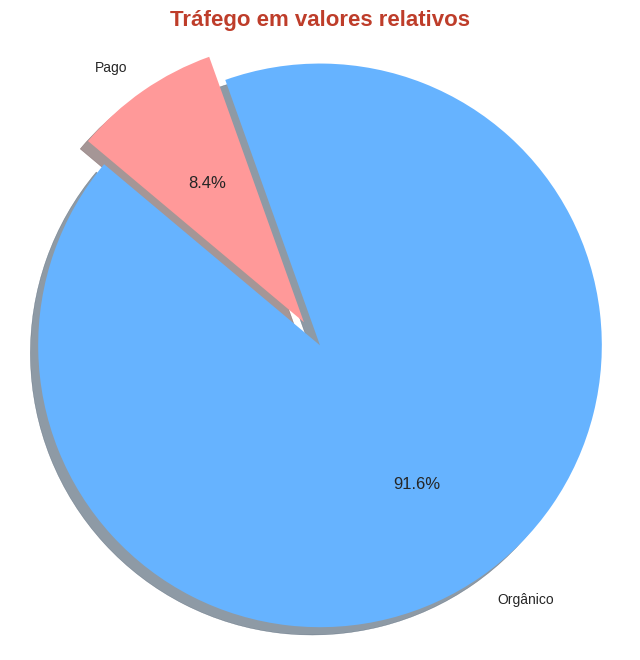

In [ ]:
# Gráfico de pizza
rotulos = ['Orgânico', 'Pago']
total = [traf_o, traf_p]
cores = ['#66b3ff', '#ff9999']
limites = (0.1, 0)

plt.figure(figsize=(8, 8))
plt.pie(total, explode=limites, labels=rotulos, colors=cores, autopct='%1.1f%%',
        shadow=True, startangle=140)
plt.axis('equal')
plt.title('Tráfego em valores relativos', fontsize=16, weight='bold', color='#BE3D2A')
plt.show()

**Análise:**

* Se o total de visitas no site no período de 2 anos e 1 mês foi de 11787 e o total de cliques nos anúncios foi de 994, então o investimento em campanhas trouxe apenas 8,4% de leads. Os outros 91,6% (10793 visitas) são de tráfego orgânico: artigos em blogs, vídeos no Youtube, postagens em redes sociais (todos com links apontando para o site), pesquisas em buscadores como o Google, QR Codes, etc.

**Observações:**

* Não tem dados suficientes para comprovar algo sobre o tráfego orgânico neste dataset, mas são hipóteses muito contundentes.

**Recomendação:**

* Coletar mais dados sobre a origem das visitas e das conversões para que seja possível calcular o ROI (Retorno sobre o investimento) e também as vendas realizadas através do tráfego orgânico. Assim os gestores poderão tomar decisões de investimentos em campanhas baseadas no dados para ter um melhor direcionamento.

In [ ]:
# Conversões
total_visitas = df_lim['N_visitas_site'].sum()
print('Visitas no site: ', total_visitas)

total_compras = df_lim['n_compras_site'].sum()
print('Vendas: ', total_compras)

total_n_compras = total_visitas - total_compras
print('Não comprou: ', total_n_compras)

conversoes = round(((df_lim['n_compras_site'].sum() / df_lim['N_visitas_site'].sum()) * 100), 2)
print('A taxa de conversão do site é de: ', conversoes, '%')

Visitas no site:  11787
Vendas:  9053
Não comprou:  2734
A taxa de conversão do site é de:  76.8 %


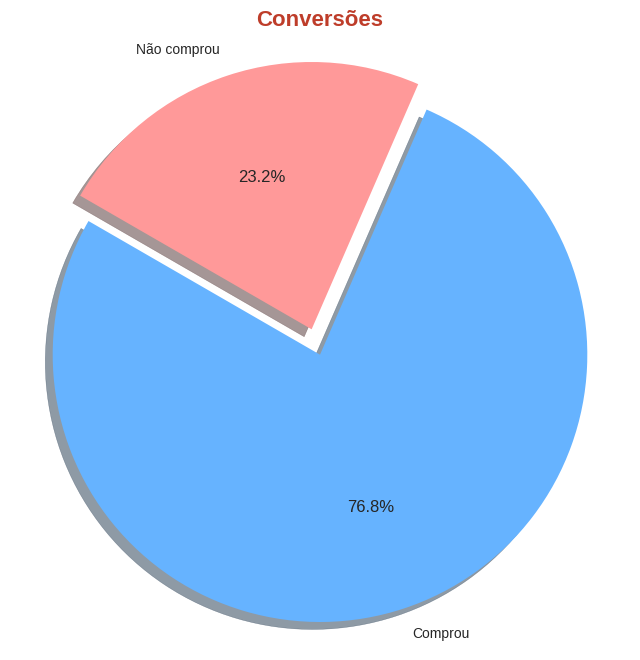

In [ ]:
# Gráfico de pizza
rotulos = ['Comprou', 'Não comprou']
total = [total_compras, total_n_compras]
cores = ['#66b3ff', '#ff9999']
limites = (0.1, 0)

plt.figure(figsize=(8, 8))
plt.pie(total, explode=limites, labels=rotulos, colors=cores, autopct='%1.1f%%',
        shadow=True, startangle=150)
plt.axis('equal')
plt.title('Conversões', fontsize=16, weight='bold', color='#BE3D2A')
plt.show()

**Análise:**

- A conversão do site foi de 76% (9.053 vendas de 11.787 visitas);

**Observações:**

- Não dá para segmentar essas vendas, ou seja, não tem como descobrir através deste dataset se as conversões vieram do tráfego orgânico ou do pago. A única informação é que o tráfego pago trouxe 994 visitas para o site, mas não se sabe quantos deles compraram ou não;

**Recomendações:**

- Capturar mais dados sobre as conversões por canais de vendas para que possa ser feita uma melhor segmentação;

- Organizar os dados em tabelas de fato e de dimensões, separando-as por vendas (fato), canais de vendas, tráfego pago, dados do cliente, produtos, etc (dimensões).

### Descontos

In [ ]:
df_lim.columns

Index(['ID', 'Ano_nascimento', 'Idade_cliente', 'Faixa_etaria', 'Estado_civil',
       'Renda_anual', 'Classe_social', 'Nivel_educacao', 'Num_criancas',
       'Num_adolescentes', 'Data_cadastro', 'Dia_cadas', 'Mes_cadas',
       'Ano_cadas', 'Data_compra_1', 'Dia_comp_1', 'Mes_comp_1', 'Ano_comp_1',
       'Intervalo_dias', 'N_visitas_site', 'n_compras_site', 'Compras_catal',
       'Compras_loja_f', 'Compras_total_q', 'Valor_p_vinho', 'Valor_p_frutas',
       'Valor_p_carne', 'Valor_p_pesca', 'Valor_p_doces', 'Valor_p_ouro',
       'Receita_total', 'Compras_desc', 'Reclamou', 'Aceitou_1', 'Aceitou_2',
       'Aceitou_3', 'Aceitou_4', 'Aceitou_5', 'Aceitou_na_ultima',
       'Valor_contato', 'Valor_apos_ac'],
      dtype='object')

In [ ]:
# 'Compras_desc' fazer alguma análise para essa variável # Parei aqui
df_lim['Compras_desc']

,Compras_desc
0,3
1,2
2,1
3,2
4,5
...,...
2211,2
2212,7
2213,1
2214,2


###Tendências

Text(0.5, 1.02, 'Tendência de incrição de clientes ao longo dos anos')

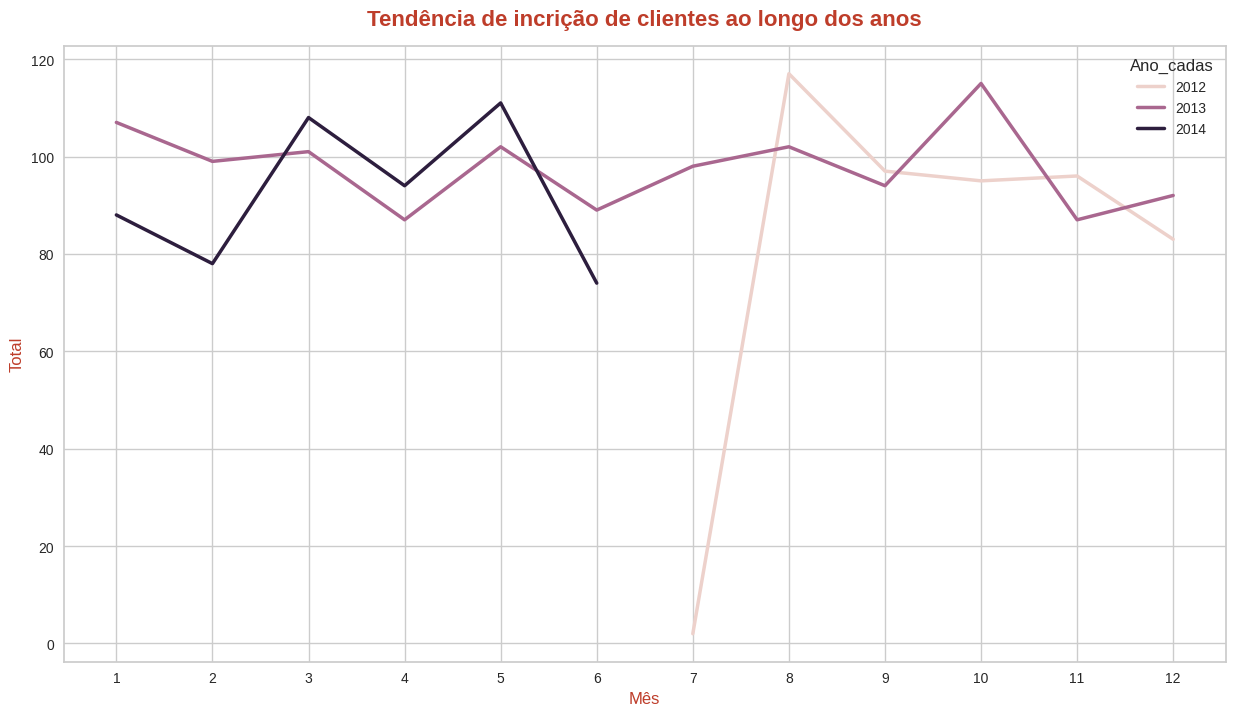

In [ ]:
# Agrupando por ano e mês
ag_ano_mes = df_lim.groupby(['Ano_cadas', 'Mes_cadas']).size().reset_index(name='Total')

# Plotando os dados
fig, ax = plt.subplots(figsize=(15, 8))
ax=sns.lineplot(data=ag_ano_mes, x='Mes_cadas', y='Total', hue='Ano_cadas', linewidth=2.5,)
plt.xlabel('Mês', fontsize=12, color='#BE3D2A')
plt.ylabel('Total', fontsize=12, color='#BE3D2A')
plt.xticks(range(1,13))
plt.title('Tendência de incrição de clientes ao longo dos anos', fontsize=16, weight='bold', color='#BE3D2A', y=1.02)

**Análise:**

- Quedas no meses de fevereiro e abril e subidas no meses de março e maio para os anos de 2013 e 2014;

- Um grande aumento em agosto de 2012 e outubro dos anos 2012 e 2013, com queda em novembro (mês da Black Friday) e um leve aumento em dezembro.

**Observações:**

- Analisando o gráfico de série temporal é possivel perceber que os dados são inconsistentes porque faltam registros dos anos de 2012 e 2014; a única série completa é a de 2013. Mas ainda assim dá para extrair alguns insights.

**Recomendações:**

- Coletar dados de forma consistente, sem interrupções na série temporal, para que possa ser feita uma análise mais confiável;

- O cadastro de novos clientes em queda nos últimos meses do ano não faz tanta diferença já que mais clientes não garante mais vendas. Ou seja, podem se cadastrar centenas de novos leads que não fazem uma compra sequer no site;

- A tendência se manteve equilibrada entre 75 e 120, sem quedas ou aumentos muito acentuados. Com excessão dos dados faltantes de 2012, que começa no mês de julho.

In [ ]:
# Intervalo de dias entre o cadastro no site e a primeira compra
df_lim['Intervalo_dias'].describe()

,Intervalo_dias
count,2216.00
mean,49.01
std,28.95
min,0.00
25%,24.00
50%,49.00
75%,74.00
max,99.00


**Análise**

- **mean:** a média de dias entre o cadastro no site e a primeira compra do cliente foi de 49 dias;

- **std:** o desvio padrão é 29 dias, isso significa que o número varia em 29 dias em relação a média para mais ou para menos. Se a média é 49, então os dias podem variar de 20 a 79 aproximadamente até o cliente fazer a primeira compra;

- **min:** o mínimo é zero, que são clientes que fizeram o cadastro e a compra no mesmo dia;

- **1° Quartil:** de 0 a 25% dos clientes fizeram compras em até 24 dias após o cadastro;

- **2° Quartil:** de 25% a 50% dos clientes fizeram compras em até 49 dias após o cadastro;

- **3° Quartil:** de 50% a 75% dos clientes fizeram compras em até 74 dias após o cadastro;

- **4° Quartil:** de 75% a 100% dos clientes fizeram compras em até 99 dias após o cadastro;

- **max:** os clientes que demoraram mais tempo para comprar depois de se cadastrarem foi de 99 dias.

**Conclusão**

Os clientes continuaram comprando de forma bem equilibrada mesmo depois de efetuar o cadastro; não houve um pico inicial nas compras e depois uma queda.

# Correlação

In [ ]:
# Correlação entre as variáveis numéricas
df_lim.iloc[:, 5:].corr(numeric_only=True)

,Renda_anual,Num_criancas,Num_adolescentes,Dia_cadas,Mes_cadas,Ano_cadas,Dia_comp_1,Mes_comp_1,Ano_comp_1,Intervalo_dias,...,Compras_desc,Reclamou,Aceitou_1,Aceitou_2,Aceitou_3,Aceitou_4,Aceitou_5,Aceitou_na_ultima,Valor_contato,Valor_apos_ac
Renda_anual,1.00,-0.43,0.02,-0.03,-0.01,0.02,0.01,-0.01,0.02,-0.00,...,-0.08,-0.03,0.28,0.09,-0.02,0.18,0.34,0.13,NaN,NaN
Num_criancas,-0.43,1.00,-0.04,-0.00,-0.02,0.05,0.00,-0.01,0.05,0.01,...,0.22,0.04,-0.17,-0.08,0.02,-0.16,-0.21,-0.08,NaN,NaN
Num_adolescentes,0.02,-0.04,1.00,0.01,-0.01,-0.01,-0.01,-0.01,-0.01,0.01,...,0.39,0.00,-0.14,-0.02,-0.04,0.04,-0.19,-0.15,NaN,NaN
Dia_cadas,-0.03,-0.00,0.01,1.00,-0.00,0.01,0.07,0.02,0.04,0.01,...,-0.01,-0.01,0.00,0.02,-0.00,0.01,-0.03,-0.01,NaN,NaN
Mes_cadas,-0.01,-0.02,-0.01,-0.00,1.00,-0.62,-0.03,0.38,-0.37,0.01,...,0.02,-0.01,-0.01,-0.02,-0.01,-0.01,-0.04,0.03,NaN,NaN
Ano_cadas,0.02,0.05,-0.01,0.01,-0.62,1.00,0.05,-0.29,0.88,-0.03,...,-0.19,-0.02,0.04,0.00,0.01,-0.01,0.02,-0.17,NaN,NaN
Dia_comp_1,0.01,0.00,-0.01,0.07,-0.03,0.05,1.00,0.01,-0.00,0.01,...,-0.01,-0.04,0.03,0.02,0.05,-0.01,-0.00,-0.00,NaN,NaN
Mes_comp_1,-0.01,-0.01,-0.01,0.02,0.38,-0.29,0.01,1.00,-0.57,-0.01,...,0.02,-0.02,-0.01,-0.04,0.01,-0.03,-0.03,0.04,NaN,NaN
Ano_comp_1,0.02,0.05,-0.01,0.04,-0.37,0.88,-0.00,-0.57,1.00,0.10,...,-0.19,-0.02,0.03,0.01,-0.00,0.00,0.02,-0.20,NaN,NaN
Intervalo_dias,-0.00,0.01,0.01,0.01,0.01,-0.03,0.01,-0.01,0.10,1.00,...,0.00,0.01,-0.02,-0.00,-0.03,0.02,-0.00,-0.20,NaN,NaN


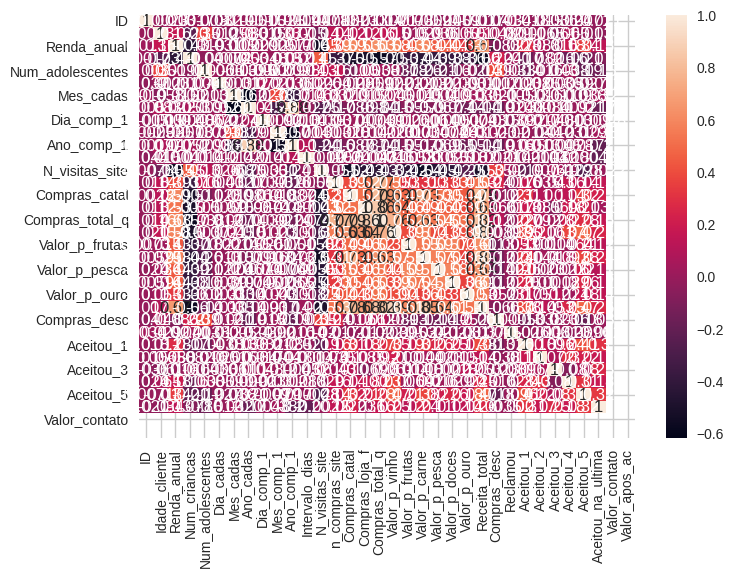

In [ ]:
#  Heatmap sem opções
sns.heatmap(df_lim.corr(numeric_only=True), annot=True);

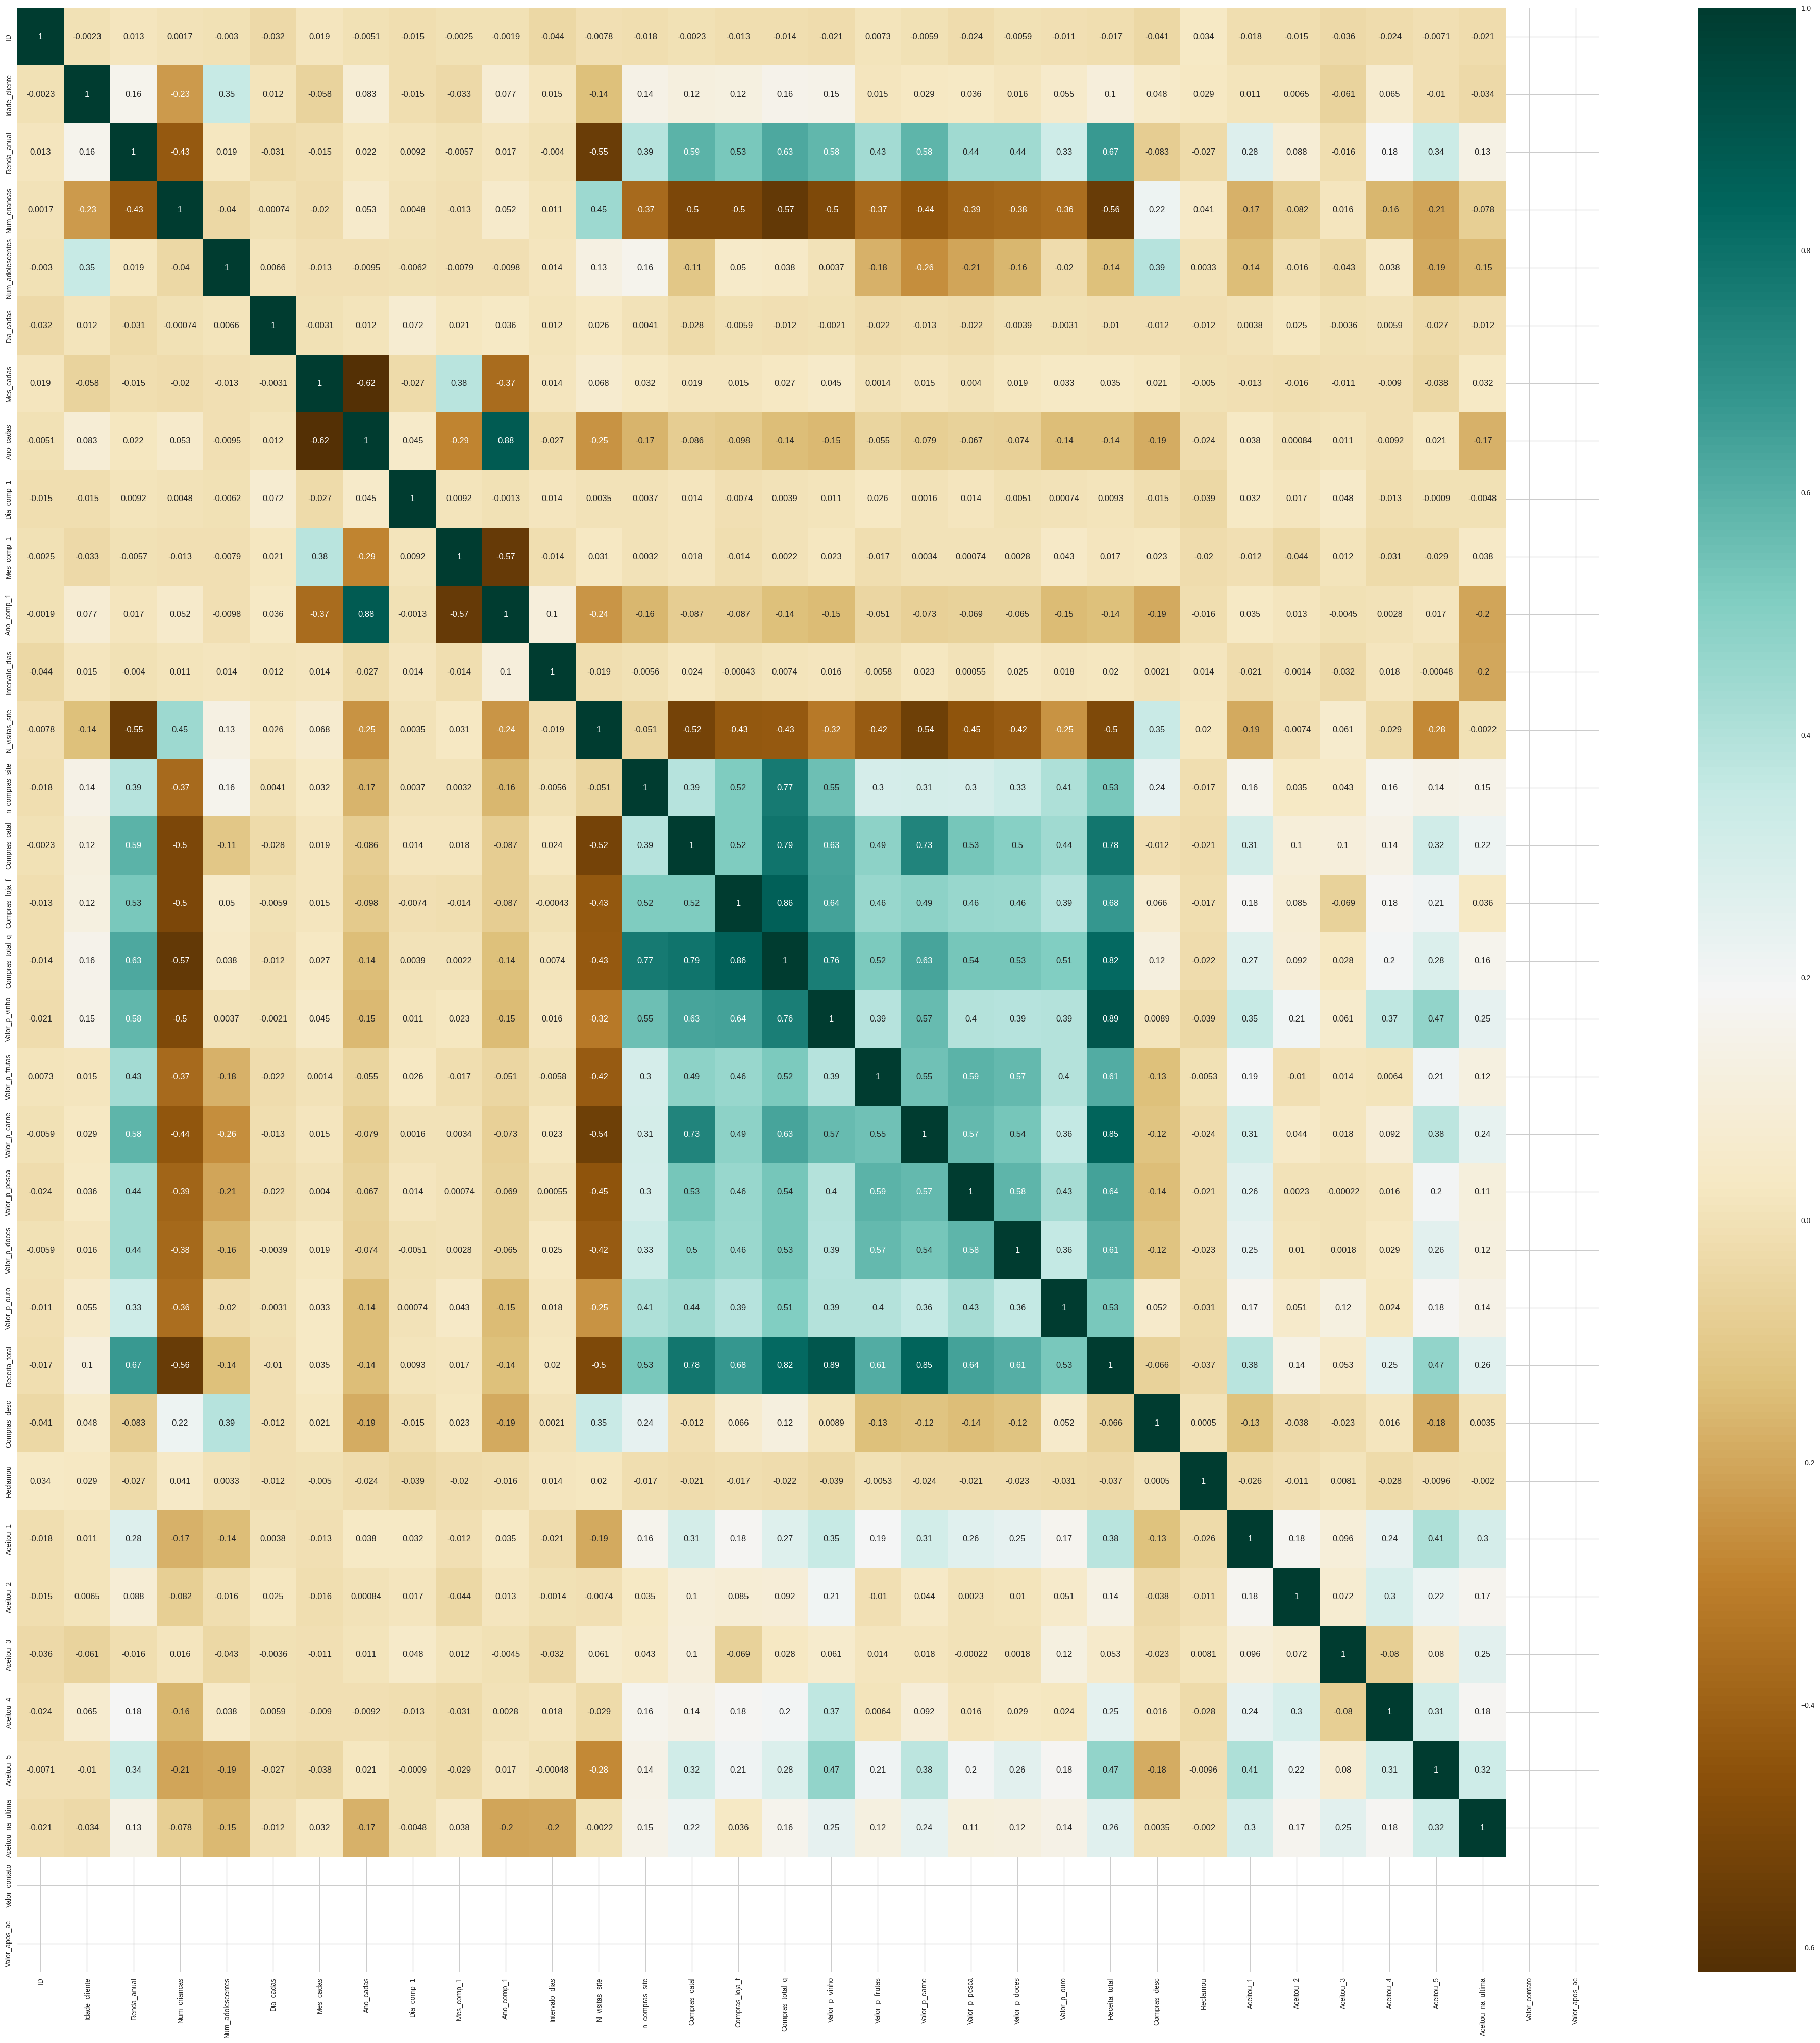

In [ ]:
#  Heatmap com opções
plt.figure(figsize=(50,50))
sns.heatmap(df_lim.corr(numeric_only=True), cmap='BrBG', annot=True);

### Correlação por lista (não precisa ficar procurando no heatmap)

Fazer a correlação somente entre as variáveis mais importantes

In [ ]:
correl = df_lim.corr(numeric_only = True)['Receita_total'].sort_values()
correl

,Receita_total
Num_criancas,-0.56
N_visitas_site,-0.50
Ano_cadas,-0.14
Num_adolescentes,-0.14
Ano_comp_1,-0.14
Compras_desc,-0.07
Reclamou,-0.04
ID,-0.02
Dia_cadas,-0.01
Dia_comp_1,0.01


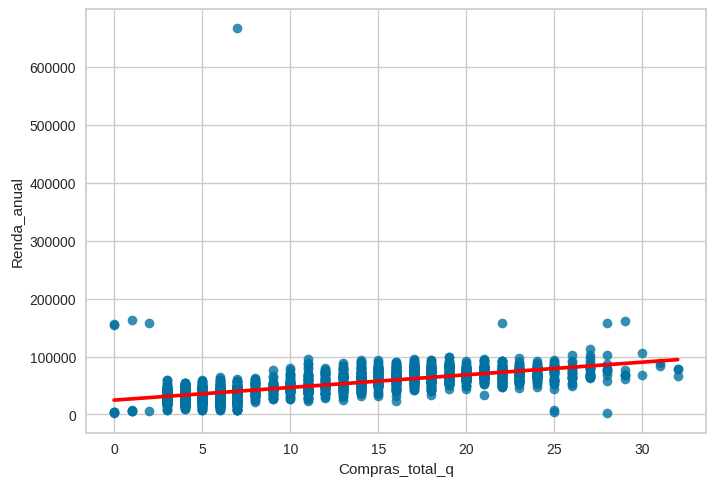

In [ ]:
# A correlação é linear?
sns.regplot(x=df_lim['Compras_total_q'], y=df_lim['Renda_anual'], line_kws={'color':'red'});

**Análise:**

Entre todas as variáveis, a única correlação importante que pode ser analisada é entre as variáveis 'Compras_total_q' e 'Renda_anual', que é fraca (0.63). Essa correlação indica que as variáveis se movem no mesmo sentido, ou seja, quanto maior é a renda anual do cliente, maior é a quantidade de compras na loja. Correlação não implica causalidade, apenas indica que as variáveis se movem juntas.